# **Desarrollo de Actividad 2: Explorando el modelado predictivo: regresión lineal multiple y regularizada**

**Proyecto:** Aplicación de modelos predictivo en el analisis de  uso del smartphone.

**Presentado por:**

•	Adriana Patricia Rodriguez Toloza

**Fecha:** 12 de mayo de 2026

## **Selección y descripción de la base de datos:**

La base de datos seleccionada se llama "Smartphone usage addiction analysis", disponible en la plataforma kaggle, y contiene información acerca de los patrones de uso de smartphones e indicadores del nivel de adicción de 7500 individuos. El dataset contiene las siguientes variables:


*   **Transaction_id:** Identificador de la transacción
*   **User_id:** Identificador del usuario
*   **Age:** Edad
*   **Gender:** Género
*   **Daily_screen_time_hours:** Horas diarias de uso del smartphone
*   **Social_media_hours:** Tiempo en horas en redes sociales
*   **Gaming_hours:** Tiempo en horas en videojuegos
*   **Work_study_hours:** Horas de trabajo o estudio
*   **Sleep_hours:** Horas de sueño
*   **Nottificatios_per_day:** Número de notitficaciones por día
*   **App_opens_per_day:** Número de veces que abre aplicaciones al día
*   **Weekend_screen_time:** Tiempo en pantalla en fines de semana
*   **Stress_level:** Nivel de estrés
*   **Academic_work_impact:** Impacto sobre el rendimiento académico o laboral
*   **Addiction_level:** Nivel de adicción
*   **Addicted_label:** Etiqueta del nivel de adicción (Variable Binaria donde 0 es baja, 1 es media o severa)

Para esta base de datos, las variables Transaction_id e User_id son equivalentes y cumplen la función de identificar registros.


## **Contexto y análisis del problema:**

Desde el desarrollo de las diferentes funciones de los smartphones ha generado importantes beneficios en términos de rapidez y conectividad, sin embargo, también ha propiciado una creciente dependencia a estos dispositivos.

 La Organización Mundial de la Salud (2018) ha manifestado su preocupación sobre las implicaciones del uso excesivo de dispositivos electrónicos a la salud pública. Entre las principales consecuencias se destacan la baja autoestima, los cambios de humor, los trastornos del sueño como el insomnio, así como molestias físicas como dolor y rigidez en el cuello, sequedad ocular, síndrome de visión por ordenador y debilidad en el pulgar, entre otras (National Library of Medicine, 2016).

Asimismo, se han identificado nuevos trastornos y comportamientos asociados, como la “textiedad” (ansiedad por no recibir o enviar mensajes de texto), el síndrome de vibración o zumbido fantasma (percepción ilusoria de que el teléfono suena o vibra) y la conducta conocida como communifaking, en la cual el individuo simula estar ocupado en interacciones digitales para evitar conversaciones presenciales, buscar aceptación social o proyectar una determinada imagen.

En este contexto, se abordará el análisis de una base de datos compuesta por 7.500 personas, con el fin de identificar patrones de comportamiento y desarrollar modelos que permitan detectar y predecir niveles de adicción a dispositivos móviles. Esto contribuirá al diseño de estrategias de prevención e intervención orientadas a mitigar los impactos negativos en la salud mental.


## **Selección de variable predictoria:**


La variable cuantitativa de predicción será el **índice de adicción.**

## **Paso 1: Cargue de información:**

### ***1.1 Importar librerias***

In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.api as smt

from scipy.stats import skew, kurtosis, normaltest, kurtosistest, pearsonr,stats, shapiro
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold,cross_validate
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import linear_rainbow



### ***1.2 Conectar al drive:***

---



In [105]:
from google.colab import drive #Importo el módulo drive del paquete google.colab
drive.mount("/content/drive") #Monto mi drive en la ruta especificada

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ***1.3 Lectura de la base de datos:***


In [106]:
df=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Supervisados/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv") #Utilizo pandas para leer la base de datos
df.head() #Visualización de las primeras filas

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


### ***1.4 Identificación del tipo de variables y renombre de las mismas:***

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

Con el fin de facilitar la interpreación de las variables, se decide realizar el renombre de las mismas.

In [108]:
#Renombre de las variables
df.rename(columns={
          'transaction_id':"ID Transacción",
          'user_id':"ID Usuario",
          'age':"Edad",
          'gender':"Género",
          'daily_screen_time_hours':"Tiempo de uso diario del smartphone (Horas)" ,
          "social_media_hours": "Tiempo de uso de redes sociales (Horas)",
          'gaming_hours':"Tiempo usado en videojuegos (Horas)",
          'work_study_hours':"Tiempo destinado a trabajo o estudio (Horas)",
          'sleep_hours':"Horas de sueño",
          'notifications_per_day':"Número de notificaciones por día",
          'app_opens_per_day':"Número de veces que abre aplicaciones al día",
          'weekend_screen_time':"Tiempo en pantalla los fines de semana",
          'stress_level':"Nivel de estrés",
          'academic_work_impact':"Impacto sobre el rendimiento académico o laboral",
          'addiction_level':"Nivel de adicción",
          'addicted_label':"Indice de adicción"},
          inplace=True)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   ID Transacción                                    7500 non-null   object 
 1   ID Usuario                                        7500 non-null   object 
 2   Edad                                              7500 non-null   int64  
 3   Género                                            7500 non-null   object 
 4   Tiempo de uso diario del smartphone (Horas)       7500 non-null   float64
 5   Tiempo de uso de redes sociales (Horas)           7500 non-null   float64
 6   Tiempo usado en videojuegos (Horas)               7500 non-null   float64
 7   Tiempo destinado a trabajo o estudio (Horas)      7500 non-null   float64
 8   Horas de sueño                                    7500 non-null   float64
 9   Número de notificac

Con el método .info() es posible identificar que la base de datos está compuesto por 7500 registros y 16 columnas. De esas 16 columnas tenemos:
* 6 variables del tipo texto (categórica):
  * Identificador de la transacción (Ordinal)
  * Identificador del usuario (Ordinal)
  * Género (Nominal)
  * Nivel de estrés (Ordinal)
  * Impacto sobre el rendimiento académico o laboral (Nominal)
  * Nivel de adicción (Ordinal)
* 6 variables numéricas del tipo continua:
  * Tiempo de uso diario del smartphone (Horas)
  * Tiempo de uso de redes sociales (Horas)
  * Tiempo usado en videojuegos (Horas)
  * Tiempo destinado a trabajo o estudio (Horas)
  * Horas de sueño
  * Tiempo en pantalla en fines de semana
* 4 variables numéricas discretas:
  * Edad
  * Número de notificaciones por día
  * Número de veces que abre aplicaciones al día
  * Indice de adicción

La variable numérica "Indice de adicción" (y su equivalente categórica "Nivel de adicción") es la variable dependiente (Y) a pronosticar.


**Valores nulos:** Mediante el método .info() es posible identificar que la variable "Nivel de adicción" presenta 6681 valores no nulos, es decir, que de los 7500 registros cerca de 819 son nulos en esta variable.

### ***1.5 Listas de variables categóricas y numéricas:***

Con el fin de facilitar la ejecución de pasos aplicados, se realizará la diferenciación de variables categoricas y numéricas a analizar:

In [110]:
df.columns

Index(['ID Transacción', 'ID Usuario', 'Edad', 'Género',
       'Tiempo de uso diario del smartphone (Horas)',
       'Tiempo de uso de redes sociales (Horas)',
       'Tiempo usado en videojuegos (Horas)',
       'Tiempo destinado a trabajo o estudio (Horas)', 'Horas de sueño',
       'Número de notificaciones por día',
       'Número de veces que abre aplicaciones al día',
       'Tiempo en pantalla los fines de semana', 'Nivel de estrés',
       'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción',
       'Indice de adicción'],
      dtype='object')

> Es importante tener en cuenta que la variable "Indice de adicción" es una variable binaria (0 y 1) en la cual representa el nivel de adicción. Por lo cual, se puede utilizar para analizar su información mediante gráficos de barras o porcentuales en lugar de histogramas.}

In [111]:
#Dentro de las variables categoricas se eliminan las variables de tipo identificatoria (ID)
variables_categoricas=df.select_dtypes(exclude=[np.number]).columns.tolist()
variables_categoricas.remove("ID Transacción")
variables_categoricas.remove("ID Usuario")
print(variables_categoricas)

['Género', 'Nivel de estrés', 'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción']


In [112]:
variables_numericas=df.select_dtypes(include=[np.number]).columns.tolist()
variables_numericas

['Edad',
 'Tiempo de uso diario del smartphone (Horas)',
 'Tiempo de uso de redes sociales (Horas)',
 'Tiempo usado en videojuegos (Horas)',
 'Tiempo destinado a trabajo o estudio (Horas)',
 'Horas de sueño',
 'Número de notificaciones por día',
 'Número de veces que abre aplicaciones al día',
 'Tiempo en pantalla los fines de semana',
 'Indice de adicción']

## **Paso 2. Reporte de la calidad de los datos:**

### ***2.1 Determinación de registros duplicados:***

In [113]:
df.duplicated().sum()

np.int64(0)

Se evidencia que la base de datos no presenta registros duplicados.

### ***2.2 Porcentaje de valores nulos:***

In [114]:
(df.isnull().sum()/df.isnull().count())*100 #Porcentaje de valores nulos: primero con isnull() evalúo si es un valor nulo donde  1 es verdadero y 0 es falso. Luego con el promedio sumo y divido por el total de los datos

,0
ID Transacción,0.00
ID Usuario,0.00
Edad,0.00
Género,0.00
Tiempo de uso diario del smartphone (Horas),0.00
Tiempo de uso de redes sociales (Horas),0.00
Tiempo usado en videojuegos (Horas),0.00
Tiempo destinado a trabajo o estudio (Horas),0.00
Horas de sueño,0.00
Número de notificaciones por día,0.00


Se identifica que el 11% de los datos del nivel de adicción son nulos, por lo cual surge la necesidad de revisar los registros completos que contienen estos valores nulos.

In [115]:
# Registros con valores nulos
df[df["Nivel de adicción"].isnull()] #Con el método .isnull() evalúo cada valor de la columna "Nivel de adicción" para verificar con booleano si es o no un valor nulo, y como mascara en pandas la utilizo para filtrar unicamente los True

,ID Transacción,ID Usuario,Edad,Género,Tiempo de uso diario del smartphone (Horas),Tiempo de uso de redes sociales (Horas),Tiempo usado en videojuegos (Horas),Tiempo destinado a trabajo o estudio (Horas),Horas de sueño,Número de notificaciones por día,Número de veces que abre aplicaciones al día,Tiempo en pantalla los fines de semana,Nivel de estrés,Impacto sobre el rendimiento académico o laboral,Nivel de adicción,Indice de adicción
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
11,TXN00012,U00012,27,Other,5.16,1.82,2.27,0.93,7.79,228,32,8.10,High,Yes,NaN,0
13,TXN00014,U00014,32,Male,4.09,1.74,1.35,3.74,5.54,76,16,4.77,High,Yes,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7447,TXN07448,U07448,20,Female,5.00,1.68,2.87,1.02,6.67,237,26,5.87,Medium,Yes,NaN,0
7454,TXN07455,U07455,29,Other,3.45,3.95,1.20,1.24,7.51,25,84,5.19,High,No,NaN,0
7457,TXN07458,U07458,29,Female,3.11,2.44,3.17,0.84,8.93,217,174,4.27,High,Yes,NaN,0
7481,TXN07482,U07482,29,Male,4.72,3.65,0.78,2.58,5.15,20,76,6.02,Medium,No,NaN,0


Si se revisa nuevamente la base de datos original, es posible identificar que la variable "Nivel de adicción" es correspondiente y equivalente al valor del índice de adicción. Donde:
* Si el índice = 0, el nivel de adicción es leve
* Si el índice = 1, se conoce que el nivel de adicción es Moderado o severo

Por lo cual verificamos de manera simultanea la variable nivel de adicción como criterio para complementar:

In [116]:
#Conteo de NA en la variable "Nivel de adicción"
#Cuando "Indice de  adicción == 0"
((df["Indice de adicción"]==0)&(df["Nivel de adicción"].isnull())).sum()


np.int64(819)

In [117]:
#Cuando el "Indice de adicción == 1"
((df["Indice de adicción"]==1) & (df["Nivel de adicción"].isnull())).sum()

np.int64(0)

Vemos que todos los registros nulos de la variable "Nivel de adicción" (819) corresponden a individuos cuyo "Indice de adicción" es igual a 0. Por lo cual, utilizando el criterio anteriormente mencionado, se reemplazaran todos los NA por "Leve".

In [118]:
df["Nivel de adicción"]=df["Nivel de adicción"].fillna("Leve")

In [119]:
#Verificamos el porcentaje de valores nulos luego del reemplazo
(100*df.isnull().sum()/(df.count())).round(2)

,0
ID Transacción,0.0
ID Usuario,0.0
Edad,0.0
Género,0.0
Tiempo de uso diario del smartphone (Horas),0.0
Tiempo de uso de redes sociales (Horas),0.0
Tiempo usado en videojuegos (Horas),0.0
Tiempo destinado a trabajo o estudio (Horas),0.0
Horas de sueño,0.0
Número de notificaciones por día,0.0


De esta manera hemos podido abordar los valores nulos presentes en la base de datos.

### ***2.3 Verificación de los niveles de variables categóricas:***

In [120]:
print(variables_categoricas)

['Género', 'Nivel de estrés', 'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción']


In [121]:
for col in variables_categoricas:
  niveles=df[col].unique()
  print(niveles)

['Male' 'Other' 'Female']
['Medium' 'High' 'Low']
['Yes' 'No']
['Leve' 'Mild' 'Moderate' 'Severe']


In [122]:
df.replace({"Male": "Hombre", "Female": "Mujer", "Other":"Otro","Medium":"Medio","High":"Alto","Low":"Bajo","Yes":"Si","Mild":"Leve","Moderate":"Moderado","Severe":"Severo"},inplace=True)

In [123]:
for col in variables_categoricas:
  niveles=df[col].unique()
  print(niveles)

['Hombre' 'Otro' 'Mujer']
['Medio' 'Alto' 'Bajo']
['Si' 'No']
['Leve' 'Moderado' 'Severo']


Observamos que las variables categóricas significativas presentan los siguientes niveles:
* Género: Hombre, Mujer, Otro
* Nivel de estrés: Medio, Alto, Bajo
* Impacto sobre el rendimiento academico o  trabajo: Si y No
* Nivel de adicción: Leve, Moderado, Severo y presenta valores nulos.

## **Paso 3: Análisis descriptivo inicial:**

### ***3.1 Medidas de localización, dispersión y forma:***

In [124]:
df.describe().round(2)

,Edad,Tiempo de uso diario del smartphone (Horas),Tiempo de uso de redes sociales (Horas),Tiempo usado en videojuegos (Horas),Tiempo destinado a trabajo o estudio (Horas),Horas de sueño,Número de notificaciones por día,Número de veces que abre aplicaciones al día,Tiempo en pantalla los fines de semana,Indice de adicción
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24,0.71
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72,0.45
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58,0.00
25%,22.00,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96,0.00
50%,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26,1.00
75%,31.00,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54,1.00
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88,1.00


In [125]:
moda= df[variables_numericas].mode().T

In [126]:
#Comparación media, mediana y moda de variables numéricas
media=df[variables_numericas].mean()
mediana=df[variables_numericas].median()
comparacion=pd.DataFrame({"Media":media,"Mediana":mediana,"Moda 1":moda[0], "Moda 2": moda[1]})
comparacion


,Media,Mediana,Moda 1,Moda 2
Edad,26.568800,27.000,31.00,NaN
Tiempo de uso diario del smartphone (Horas),7.499912,7.525,8.13,NaN
Tiempo de uso de redes sociales (Horas),3.273484,3.270,0.99,3.07
Tiempo usado en videojuegos (Horas),2.014183,2.040,2.37,NaN
Tiempo destinado a trabajo o estudio (Horas),3.242420,3.230,3.07,3.66
Horas de sueño,6.737561,6.720,7.77,NaN
Número de notificaciones por día,134.257333,134.000,184.00,NaN
Número de veces que abre aplicaciones al día,97.832400,98.000,109.00,NaN
Tiempo en pantalla los fines de semana,9.243827,9.260,11.92,NaN
Indice de adicción,0.707733,1.000,1.00,NaN


####**Medidas de centralidad (Media, mediana y moda):**
* Al analizar la mediana y media de cada una de las variables (excepción: indice de adicción), se evidencia que son similares. Sin embargo,  es importante recordar que para hablar de simetria se cumple que la media, mediana y moda son la misma. Sin embargo, como podemos observar en la tabla de comparación se observa que la moda difiere de manera importante de la moda y mediana y por lo cual no se puede hablar de simetria en las variables  (como la que se presentaria en una distribución gausiana). Esto representa que los datos no tienden hacia un patrón único de comportamiento de los individuos o promedio, como se presenta en este tipo de distribución.
* La similitud entre la media y la mediana podria sugerir una posible baja cantidad o importancia de valores extremos o outliers que influyan en estas medidas de localización, permitiendo que sean similares.
* Vemos que la variables Tiempo de uso de redes sociales (Horas) y Tiempo destinado a trabajo o estudio (Horas)	son bimodales (tienen dos modas), mientras las demás variables son unimodales.
* Dada la presencia de valores promedio altos (Número de notificaciones por día) y bajos (Tiempo usado en videojuegos), muestra la necesidad de realizar escalamiento de las variables.

####**Medidas de localización (Mínimo, Q1, Mediana, Q3, Máximo):**



Para complementar el análisis, se realizará el cálculo del rango entre cuartiles (Q1,Q2,Q3 y Q4) y del rango intercuartílico (Q3-Q1):

In [127]:
# Rangos entre Q1,Q2,Q3 y Q4
df_rangos=df.copy()

rangos=[]
for col in variables_numericas:
  q1=df_rangos[col].quantile(0.25)
  q2=df_rangos[col].quantile(0.50)
  q3=df_rangos[col].quantile(0.75)
  q4=df_rangos[col].quantile(1)
  rangos.append({
      "Variable":col,
      "Rango Q2-Q1":q2-q1,
      "Rango Q3-Q2":q3-q2,
      "Rango Q4-Q3":q4-q3})
  rangos_df=pd.DataFrame(rangos)
rangos_df

,Variable,Rango Q2-Q1,Rango Q3-Q2,Rango Q4-Q3
0,Edad,5.000,4.000,4.00
1,Tiempo de uso diario del smartphone (Horas),2.305,2.285,2.19
2,Tiempo de uso de redes sociales (Horas),1.360,1.360,1.37
3,Tiempo usado en videojuegos (Horas),1.020,0.950,1.01
4,Tiempo destinado a trabajo o estudio (Horas),1.380,1.410,1.36
5,Horas de sueño,1.090,1.120,1.16
6,Número de notificaciones por día,58.000,57.000,59.00
7,Número de veces que abre aplicaciones al día,43.000,42.000,40.00
8,Tiempo en pantalla los fines de semana,2.300,2.280,3.34
9,Indice de adicción,1.000,0.000,0.00


In [128]:
#Rango Intercuartilico (Q3-Q1)
for col in variables_numericas:
  q1=df[col].quantile(0.25)
  q2=df[col].quantile(0.50)
  q3=df[col].quantile(0.75)
  IQR=(q3-q1).round(2)
  print(f"IQR de la variable {col}:",IQR)

IQR de la variable Edad: 9.0
IQR de la variable Tiempo de uso diario del smartphone (Horas): 4.59
IQR de la variable Tiempo de uso de redes sociales (Horas): 2.72
IQR de la variable Tiempo usado en videojuegos (Horas): 1.97
IQR de la variable Tiempo destinado a trabajo o estudio (Horas): 2.79
IQR de la variable Horas de sueño: 2.21
IQR de la variable Número de notificaciones por día: 115.0
IQR de la variable Número de veces que abre aplicaciones al día: 85.0
IQR de la variable Tiempo en pantalla los fines de semana: 4.58
IQR de la variable Indice de adicción: 1.0


* Los valores mínimos de las variables numéricas son factibles. Por su parte, los valores máximos de Tiempo de uso diario del smartphones en horas, Número de notificaciones por día y Número de veces que abre aplicaciones al día muestran valores llamativos pero que podrian ser posibles a factores relacionados a patrones de adicción al teléfono.
* Al observar los valores máximos de las variables es posible identificar que existe predominancia en algunas como el número de notificaciones al día (250) mientras que valores como el tiempo usado en video juegos presentan valores máximos de menor tamaño (4). Esto confirma la necesidad de hacer escalamiento para poder comparar y analizar las variables.
* Al estudiar el rango entre cuartiles (Q1,Q2,Q3 y Q4) de cada variable se evidencia que trata de ser muy homogeneo y no se encuentran saltos significativos, mostrando estabilidad en la variable. Sin embargo, el rango entre cuartiles de las diferentes variables es muy distinto, especialmente en las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día que mostraron una alta desviación estándar.
* El Rango intercuartilico IQR=(Q3-Q1) que muestra el 50% de datos central. Al encontrar un IQR tan alto en las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día, refleja que existe una alta dispersión en los datos.

####**Medidas de variabilidad (Varianza, desviación estándar y coeficiente de variación):**

In [129]:
#Varianza y Desviación estandar
varianza=(df[variables_numericas].var()).round(2)
desviacion=(df[variables_numericas].std()).round(2)

#Coeficiente de variacion
Coeficiente_de_variacion=((df[variables_numericas].std()/df[variables_numericas].mean())*100).round(2)

In [130]:
medidas_variabilidad=pd.DataFrame({"Varianza":varianza,"Desviación estándar":desviacion,"Coeficiente de variación":Coeficiente_de_variacion})
medidas_variabilidad

,Varianza,Desviación estándar,Coeficiente de variación
Edad,27.01,5.20,19.56
Tiempo de uso diario del smartphone (Horas),6.81,2.61,34.79
Tiempo de uso de redes sociales (Horas),2.51,1.59,48.43
Tiempo usado en videojuegos (Horas),1.31,1.15,56.90
Tiempo destinado a trabajo o estudio (Horas),2.56,1.60,49.37
Horas de sueño,1.65,1.28,19.05
Número de notificaciones por día,4433.81,66.59,49.60
Número de veces que abre aplicaciones al día,2344.82,48.42,49.50
Tiempo en pantalla los fines de semana,7.39,2.72,29.41
Indice de adicción,0.21,0.45,64.27


* En términos de varianza, se evidencia que las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día presentan una variabilidad significativamente alta. Por lo cual son variables con una alta dispersión de sus datos con relación a la media y por lo tanto para ser analizadas por el modelo requiere que se estandarice.
* Las variables Tiempo usado en videojuegos y Horas de suelo presentan variabilidades significativamente bajas, sin embargo, en estudios investigativos si se consideran factores importantes relacionados a la adicción como a los teléfonos.
* El coeficiente de variación para las variables Tiempo usado en videojuegos (56.90%),  Número de notificaciones por día (49.60%), Número de veces que abre aplicaciones al día (49.50%), Tiempo destinado a trabajo o estudio (49.37%)y Tiempo de uso de redes sociales (48.43%)  muestra que existe una heterogeneidad de los datos, y por lo cual los datos no se agrupan alrededor de la media sino que se encuentran esparcidos a lo largo del rango.
* Por el contrario, la edad (19.56%) y las horas de sueño (19.06%) presentan un coeficiente de variación mas bajo, lo que indica que las edades son similares (de hecho abordan los 18 y 35 años por lo que aborda rangos de adolescentes, jovenes y adultos jovenes), quienes presentan horas de sueño similares de 4 hasta 9 horas. Estas variables son por lo tanto homogeneas.



####**Medidas de forma (asimetría y curtosis):**

Para el análisis de medidas de forma se realizó el cálculo de medidas de asimetria mediante el método estandarizado de Skew y curtosis:

In [131]:
filas=[]
for col in variables_numericas:
  filas.append({
      "Variable":col,
      "Asimetria":skew(df[col]),
      "Curtosis":kurtosis(df[col])})
filas_df=pd.DataFrame(filas)
filas_df


,Variable,Asimetria,Curtosis
0,Edad,-0.020701,-1.225610
1,Tiempo de uso diario del smartphone (Horas),-0.011364,-1.215685
2,Tiempo de uso de redes sociales (Horas),-0.010256,-1.196407
3,Tiempo usado en videojuegos (Horas),-0.017234,-1.185279
4,Tiempo destinado a trabajo o estudio (Horas),0.006308,-1.215581
5,Horas de sueño,0.018709,-1.175464
6,Número de notificaciones por día,0.002711,-1.188789
7,Número de veces que abre aplicaciones al día,-0.010005,-1.218347
8,Tiempo en pantalla los fines de semana,-0.009025,-1.054737
9,Indice de adicción,-0.913507,-1.165506


**Estándares para interpretación de las medidas de forma:**
* **Asimetría:**
  * Si el coeficiente < 0 significa que tiene distribución asimetrica negativa, y se alarga a valores menores que la media
  * Si el coeficiente == 0 significa que la distribución es simétrica
  * Si el coeficiente > 0 la distribución tiene asimetria positiva, y se alarga a valores mayores que la media
* **Curtosis:**
  * Si g2 < 0 la distribución es Platicúrtica
  * Si g2 = 0 la distribución es Mesocúrtica
  * Si g2 > 0 la distribución es Leptocúrtica

Con base en los resultados observamos:
* **Edad:** presenta asimetria negativa y es del tipo Platicúrtica
* **Tiempo de uso diario del smartphone (Horas):** Presenta asimetria  negativa y es del tipo platicúrtica
* **Tiempo de uso de redes sociales (Horas):** Presenta asimetria negativa y es el tipo platicúrtica.
* **Tiempo usado en videojuegos (Horas):** Presenta asimetria negativa y es del tipo platicúrtica.
* **Tiempo destinado a trabajo o estudio (Horas):** Presenta ligera asimetria	positiva y tiene forma platicúrtica.
* **Horas de sueño:** Presenta asimetria positiva y es el tipo platicúrtica.
* **Número de notificaciones por día:** Presenta ligera asimetria positiva y es del tipo platicúrtuca.
* **Número de veces que abre aplicaciones al día:** Presenta asimetria negativa y es del tipo platicúrtica.
* **Tiempo en pantalla los fines de semana:** Presenta asimetria ligeramente negativa y es del tipo platicúrtica.

Se observa que las asimetrias son muy leves dado que los valores del coeficiente se encuentran muy cercanos a 0.


### ***3.2 Histogramas de variables cuantitativas:***

Se elaboró histogramas para el análisis de medidas de forma de las variables numéricas.

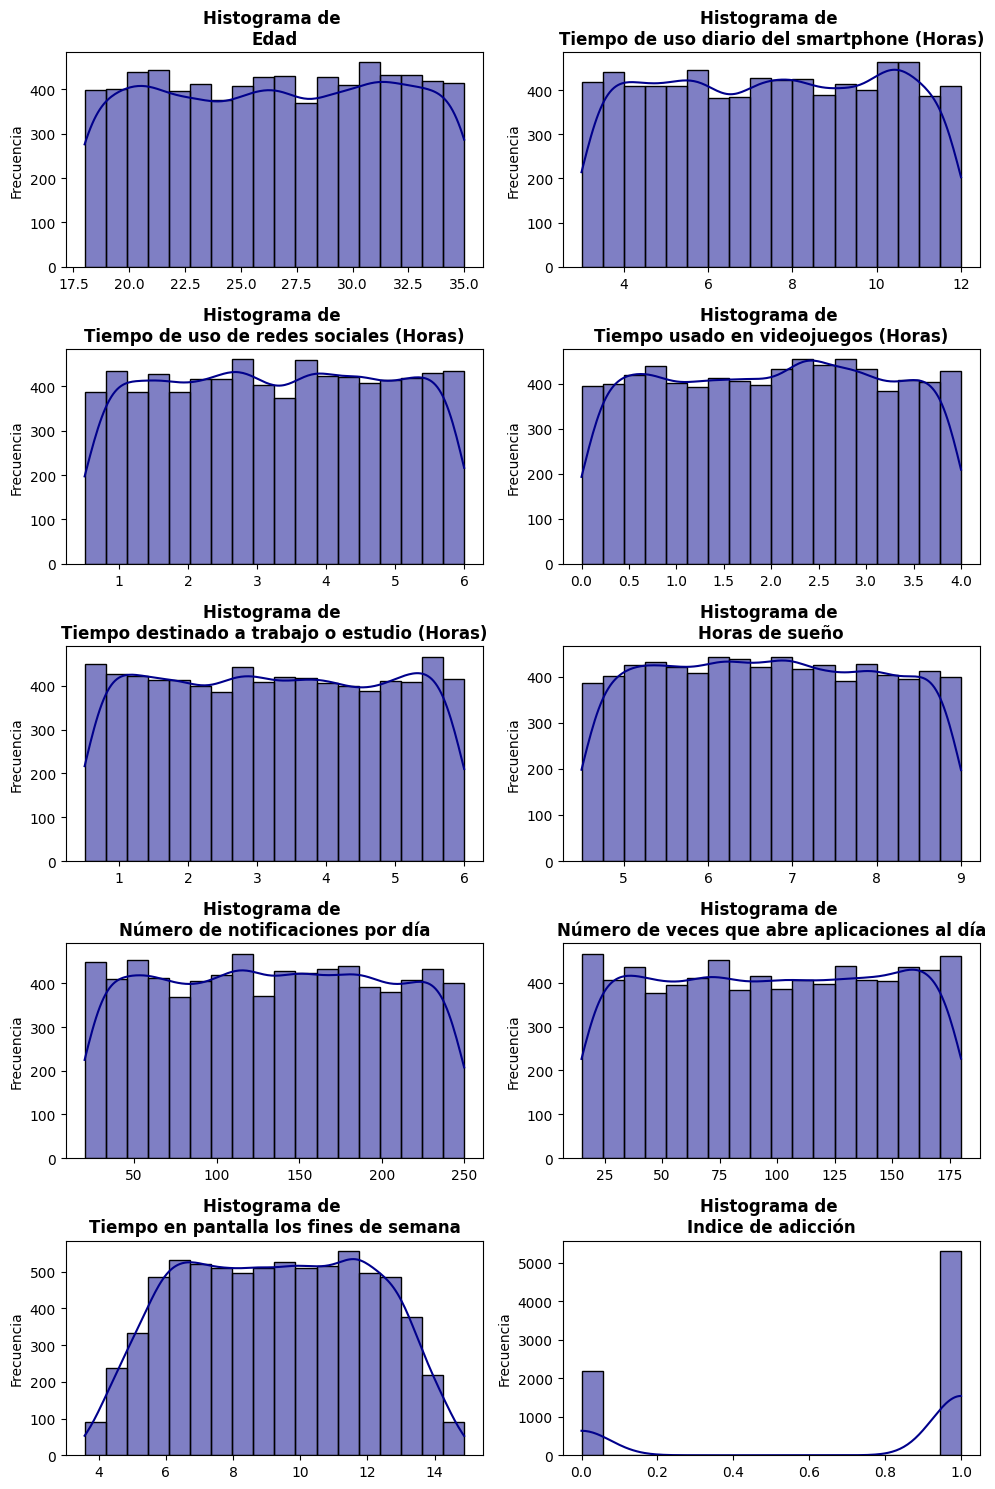

In [132]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10,15))
axes=axes.flatten()

for i,col in enumerate(variables_numericas):
  sns.histplot(df[col], edgecolor="black",bins=18,  color="darkblue",kde=True, ax=axes[i])
  axes[i].set_ylabel("Frecuencia")
  axes[i].set_xlabel("")
  axes[i].set_title(f"Histograma de \n{col}",fontweight="bold")


plt.tight_layout()
plt.show()

Los histogramas permitieron evidenciar:
* **Edad:** El gráfico de barras permite evidenciar que el rango de edad de los individuos es de 18 a 35 años, sin embargo, se encuentra distribuidos de manera similar a una distribución uniforme, donde no se evidencia concentración de edades en determinados rangos en particular, y no se evidencia valores atipicos. Dado que el rango de la variable es de los 18 a 35 años, esto refleja que la muestra está conformada por individuos adolescentes, jovenes y adultos jovenes, sin ningun sesgo hacia un grupo determinado y en un rango relativamente pequeño.

* **Tiempo de uso diario del smartphone (Horas):**  Esta variable presenta un rango pequeño de 3 a 12 horas. Se evidencia una distribución similar a la uniforme, donde los datos se distribuyen a los largo del rango y no se evidencia concentraciones o grupos muy representivos, sin embargo se observa un pico de uso en el rango de 10 a 11 horas mostrando una pequeña asimetria negativa.

* **Tiempo de uso de redes sociales (Horas):**  No se observa un grupo caracteristico hacia donde se concentren los datos. Sin embargo, entre las 3 y 4 horas se observan frecuencias significativamente altas y bajas.

* **Tiempo usado en videojuegos (Horas):** Refleja una forma platicúrtica, sin embargo se identifican algunos picos en el intervalo de 2 a 3 horas.

* **Tiempo destinado a trabajo o estudio (Horas):** Refleja una distribución cercana a la uniforme donde los valores se encuentras dispersos en el dataset y no se evidencia grupos o concentraciones significativos. Se evidencian picos cercanos a 3 horas y también cercanos a 6 horas, pero el comportamiento está distribuido de forma general a lo largo de todo el rango.
Forma: distribución bimodal.

* **Horas de sueño:** El histograma muestra una distribución un poco similar a la uniforme, homogena, y donde no se tiende hacia un intervalo especifico. Los datos están distribuidos a lo largo de un rango pequeño entre 4 y 9 horas.

* **Número de notificaciones por día:** Se obsera que los datos presentan una homogeneidad relativa, con algunos picos en intervalos pequeños, sin embargo, no se evidencia una concentración significativa hacia donde especificamente tiendan los datos.


* **Número de veces que abre aplicaciones al día:** Se encuentran picos importantes cercanos a 15 y 75 en pequeños intervalos, sin embargo los datos se encuentran distribuidos a lo largo del rango y no hay una tendencia glogal hacia donde se concentren más los datos.

* **Tiempo en pantalla los fines de semana:** Es la principal variable que muestra una concentración agrupada más clara, donde los valores entre 6 y 12 horas son más frecuentes, por lo que tienden más hacia un intervalo que a la media.

**Generalidades:**
*  Mediante los histogramas se observa que las distribuciones tienden a ser más uniformes (a excepción de la variable tiempo en pantalla los fines de semana); no existe una tendencia hacia el valor promedio sino los datos se encuentran distribuidos de manera homogenea en el rango de los datos, y esto se evidencio cuando se encontró que la moda de las variables no coincidia con la mediana y media, característica comúnn de una distribución normal.

### ***3.3 Gráficos de barras y de tortas:***

In [133]:
variables_categoricas.append("Indice de adicción") #Se decide agregar la variable de indice de adicción para poder visualizar su gráfico de barras y de tortas

/tmp/ipykernel_17884/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
/tmp/ipykernel_17884/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
/tmp/ipykernel_17884/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
/tmp/ipykernel_17884/2116879474.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

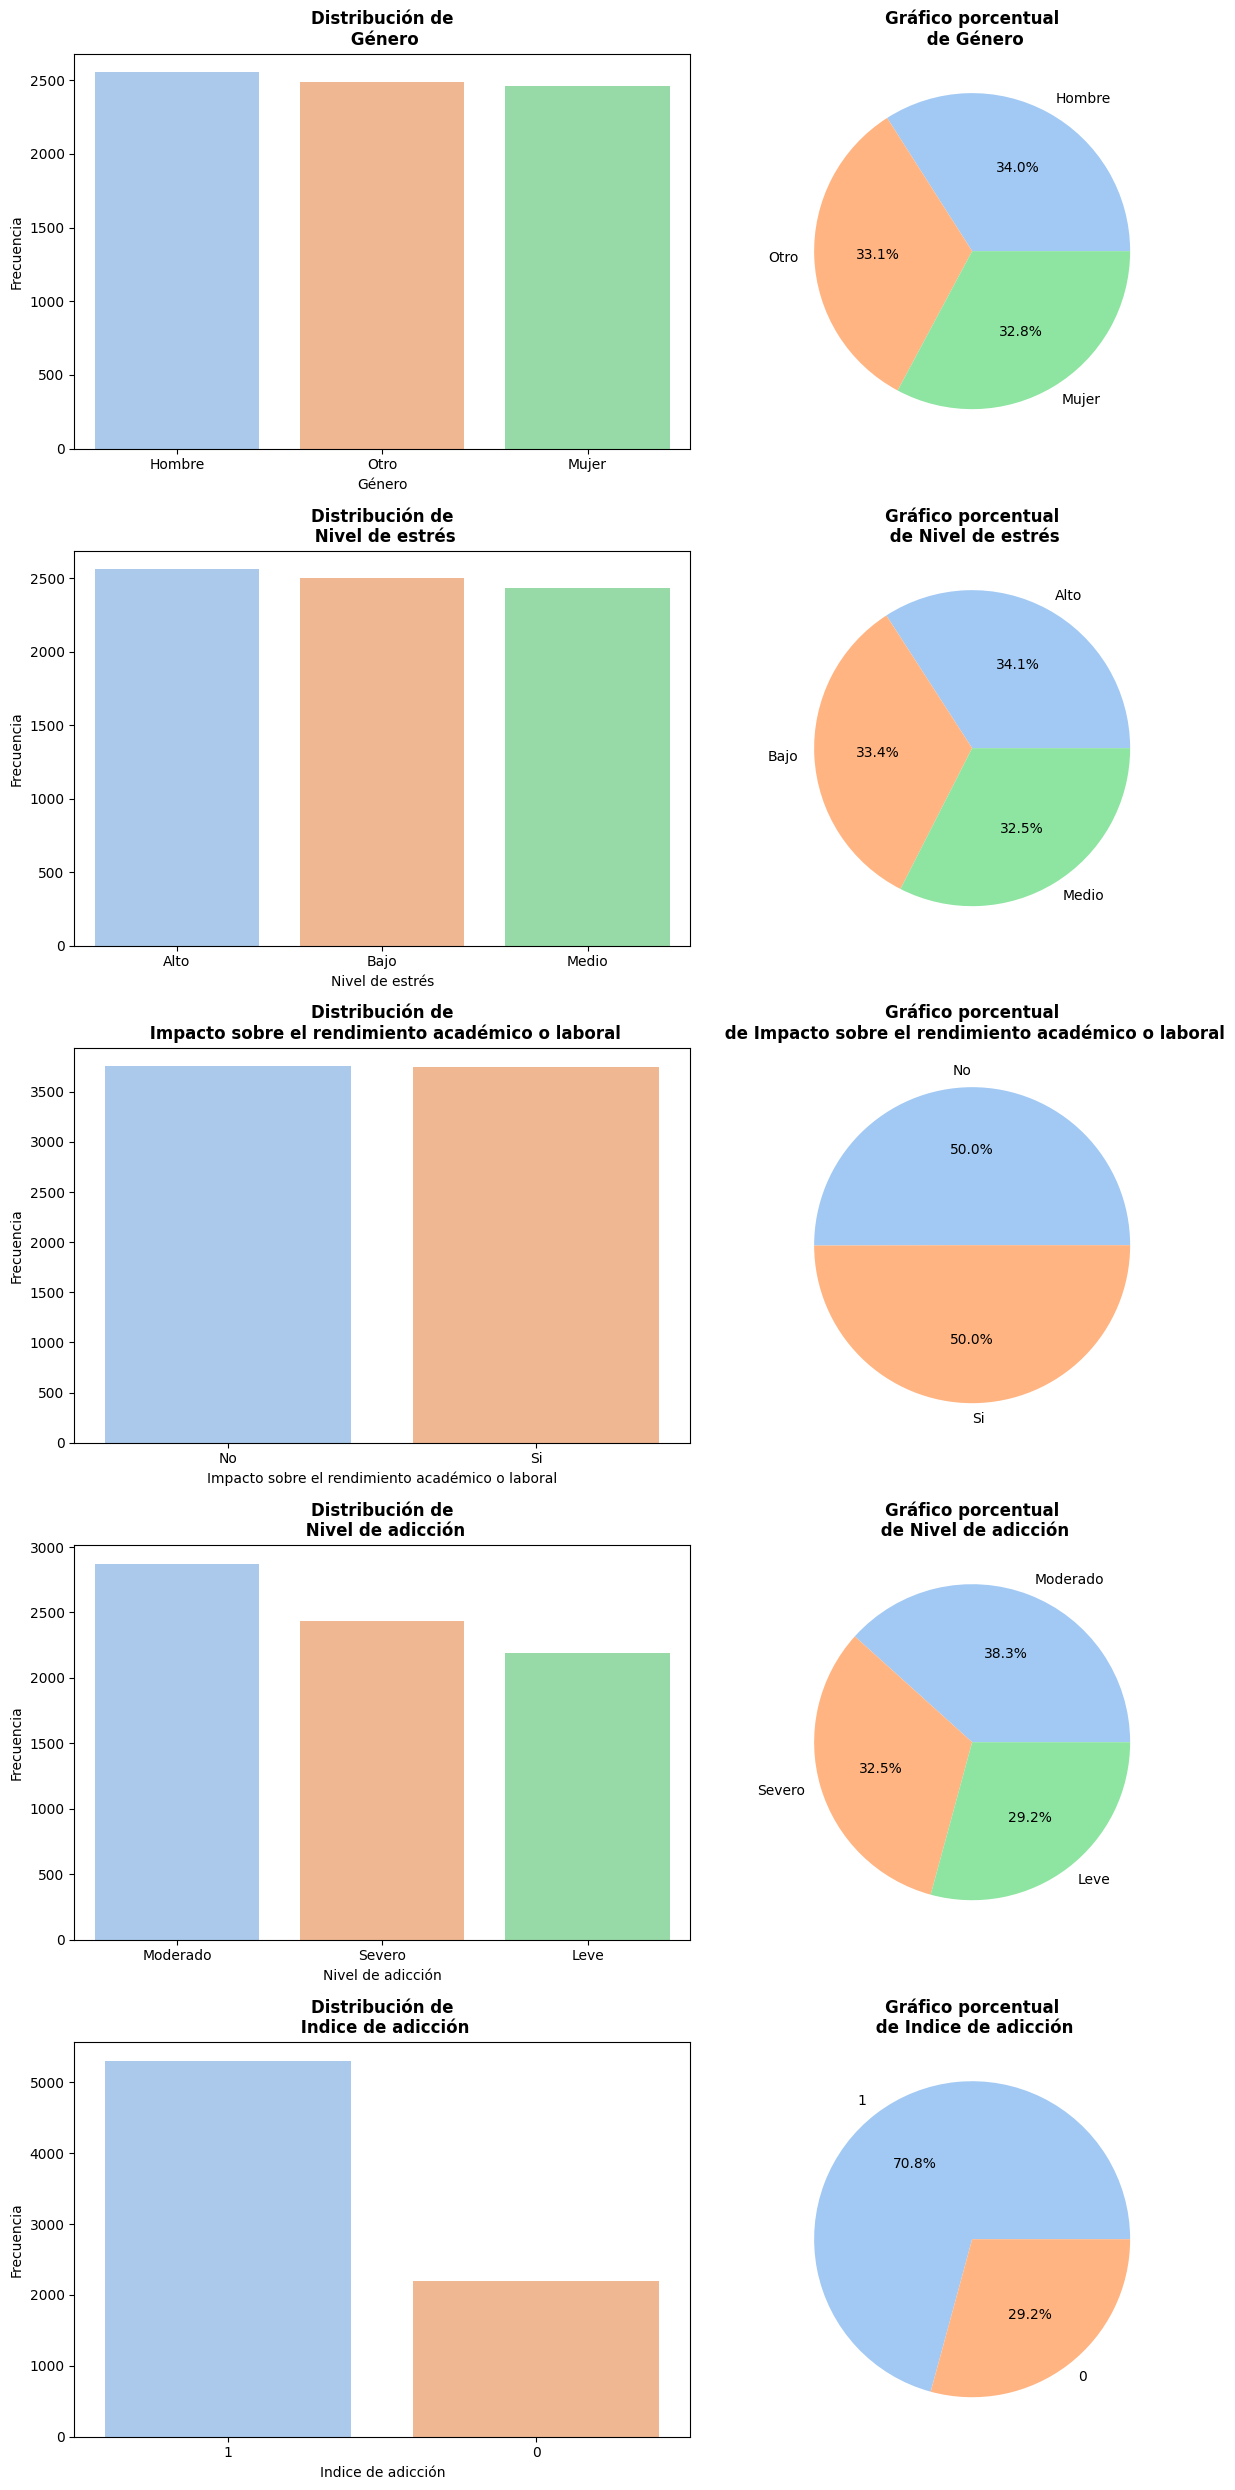

In [134]:

fig,axis=plt.subplots(nrows=len(variables_categoricas),ncols=2,figsize=(13,25))
for i, col in enumerate(variables_categoricas):
  orden = df[col].value_counts().index #Se generó la variable orden para poder hacer coincidir en los colores las gráficas de barras y de tortas
  colores = sns.color_palette("pastel", n_colors=len(orden))
  sns.countplot(x=df[col],order=orden,palette="pastel",ax=axis[i][0])
  axis[i][0].set_title(f"Distribución de\n {col}",fontweight="bold")
  axis[i][0].set_ylabel("Frecuencia")

  conteo = df[col].value_counts().loc[orden]
  axis[i][1].pie(conteo,labels=conteo.index,autopct="%1.1f%%",colors=colores)
  axis[i][1].set_title(f"Gráfico porcentual\n de {col}", fontweight="bold")
plt.tight_layout()
plt.show()

Las gráficas de barras y de tortas permiten evidenciar:
* **Género:** La distribución de género por Hombre, Mujer y otro es muy similar, no hay una predominancia que genere sesgos.
* **Nivel de estrés:** La distribución de los niveles de estrés es muy pareja, solo existen pequeñas diferencias de 0.7% entre la categoria más alta (Alto) y la más baja (bajo)
* **Impacto sobre el rendimiento académico o laboral:** Se observa que la distribución es equitativa y pareja de 50% cada una.
* **Nivel de adicción:** Existe una leve predominancia del nivel moderado (38.3%) con relación al severo (32.5%) y leve (29.2%).
* **Indice de adiccón:** El gráfico de barras muestra que 5308 registros (equivalente a 70.77%) corresponden a individuos catalogados con un índice de adicción moderado o severo. Por otra parte, 2192 registros (equivalentes al 29.23%) son categorizados con un nivel de adicción leve. Es importante recordar que esta variable cuantitativa (y su equivalente "Nivel de adicción") es la variable dependiente (Y) y es la que se utilizará también para entrenar el modelo y una vez validado se podrá utilizar para predecir resultados.


## **Paso 4: Identificar, clasificar y tratar valores faltantes:**

El tratamiento de valores faltantes se realizó en el paso 2 (Reporte de la calidad de los datos), donde se trataron los valores nulos de la variable "Nivel de adicción".


## **Paso 5: Detectar y analizar valores atípicos:**

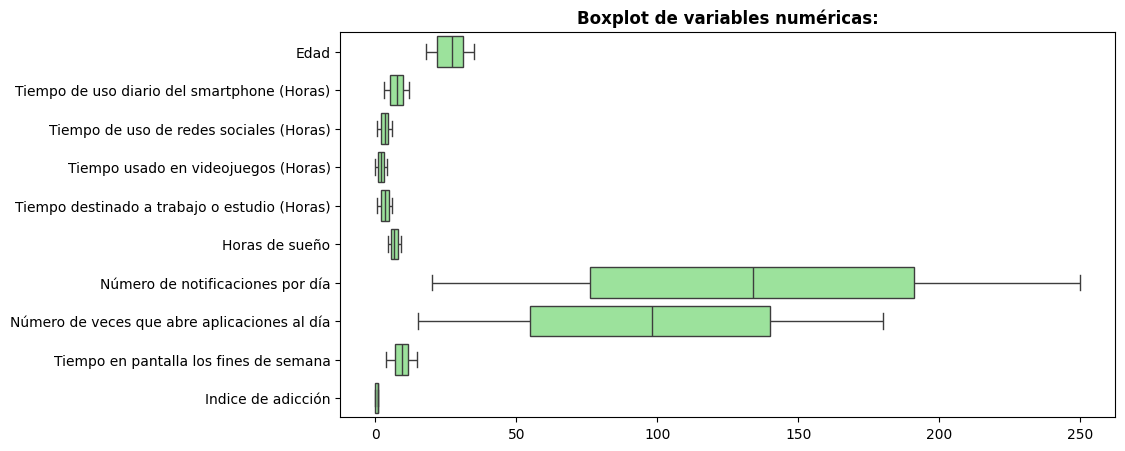

In [135]:
plt.figure(figsize=(10,5))
sns.boxplot(df,color="lightgreen",orient="h")
plt.title("Boxplot de variables numéricas:", fontweight="bold")
plt.show()

La gráfica de boxplot permite identificar:
* En las variables numéricas de la base de datos no se identifican valores atipicos teniendo en cuenta el criterio de IQR respecto al 50% de la parte central de los datos de cada variable. Sin embargo, realizando un análisis bivariado será posible exáminar otros valores atipicos.
* Se observa que las variables 'Edad','Tiempo de uso diario del smartphone (Horas)','Tiempo de uso de redes sociales ','Tiempo usado en videojuegos',   'Tiempo destinado a trabajo o estudio', 'Horas de sueño','Tiempo en pantalla los fines de semana'e'Indice de adicción' presentan un tamaño de caja menor, mostrando que son datos más agrupados cercano a la media; los bigotes también son pequeños lo que muestra que el 25% de los datos cercanos al minimo y al máximo están muy cerca del rango central (50%) de los datos.
* El tamaño de la caja y de los bigotes tan grande de las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día confirman que los datos están muy variables en estas variables, y al ser tan disperso en comparación con las demás variables, refleja la necesidad de escalar.
* Al visualizar la mediana de las variables Número de notificaciones por día y Número de veces que abre aplicaciones al día muestra que se encuentran aproximadamente en la mitad de la caja, indicando que no hay sesgos hacia determinados grupos.
* No se evidencian datos atipicos detectados por debajo o por encima de 1.5 el IQR.

Con el fin de analizar la mediana dentro de la caja de cada boxplot, se prefirió separar las variables de las de baja dispersión para hacerlas más visibles.

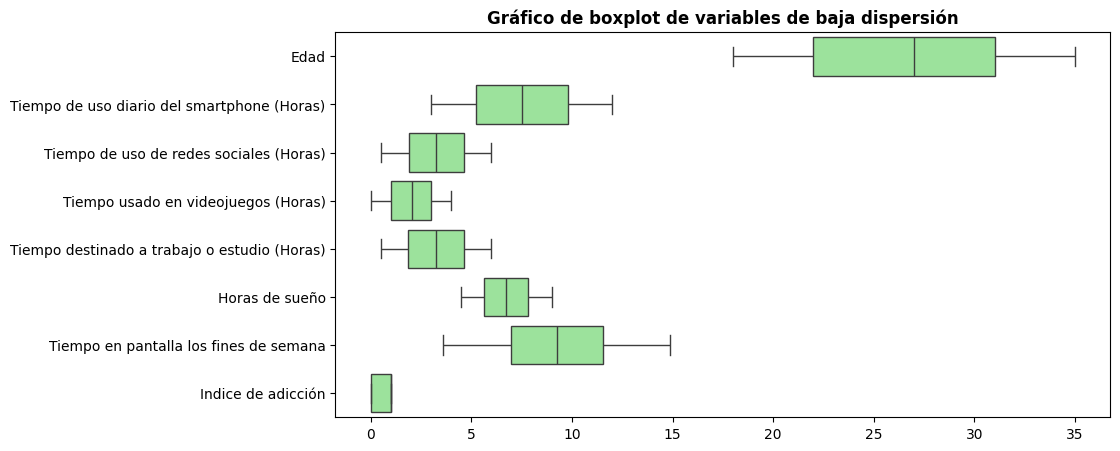

In [136]:
var_baja_dispersion=['Edad','Tiempo de uso diario del smartphone (Horas)','Tiempo de uso de redes sociales (Horas)','Tiempo usado en videojuegos (Horas)',
           'Tiempo destinado a trabajo o estudio (Horas)', 'Horas de sueño','Tiempo en pantalla los fines de semana','Indice de adicción']
plt.figure(figsize=(10,5))
sns.boxplot(df[var_baja_dispersion],color="lightgreen",orient="h")
plt.title("Gráfico de boxplot de variables de baja dispersión", fontweight="bold")
plt.show()

Es posible observar:
* La mediana del boxplot de la variable edad muestra encontrarse un poco a la derecha, mostrando una mayor concentración de valores al lado izquierdo de la mediana, con un ligero sesgo hacia edades más pequeñas.
* La mediana de las variables Tiempo de uso diario del smartphone, Tiempo de uso de redes sociales, Tiempo usado en videojuegos, Tiempo destinado a trabajo o estudio, Horas de sueño y Tiempo en pantalla los fines de semana uestran que la mediana se encuentra en una posición aproximada de la mitad en la caja.

* La mediana de la variable Indice de adicción se presenta en 1, dado que es una variable binaria conformada por 0 y 1.


## **Paso 6: Encontrar relaciones entre variables mediante matriz de correlación y análisis bivariado:**

### ***6.1 Exploración de relación entre variables mediante matriz de correlación:***

Con el fin de analizar la posible relación entre variables se decidió utilizar en primer lugar un mapa de calor de la correlación calculada entre las variables numéricas de la base de datos.

<Axes: >

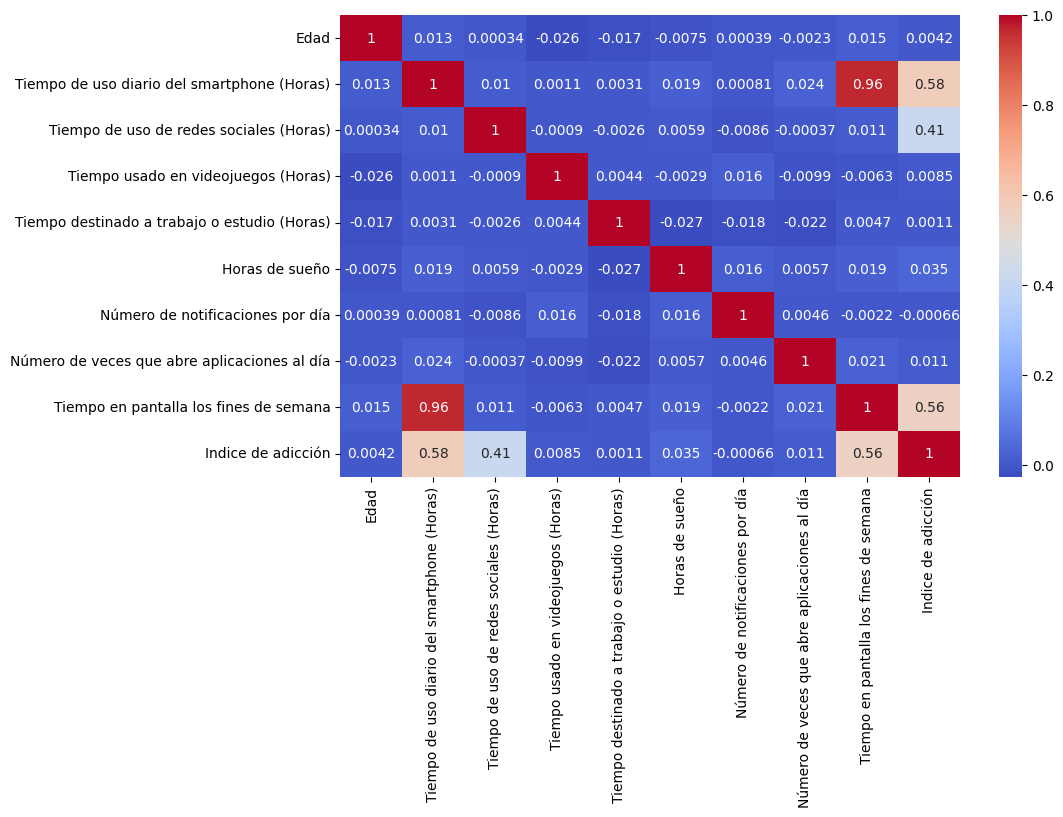

In [137]:
variables_numericas=df.select_dtypes(include=[np.number]).columns.tolist()

df[variables_numericas].corr()
plt.figure(figsize=(10,6))
sns.heatmap(df[variables_numericas].corr(),annot=True,cmap="coolwarm")


El mapa de calor permite determinar:
* Una correlación fuerte y positiva entre las variables tiempo de uso diario del smartphone y tiempo en pantalla los fines de semana. Indicando que aquellos usuarios que utilizan el celular en alta intensidad de manera diaria, también lo hacen los fines de semana.
* Se observa correlaciones bajas entre la edad y las demás variables, indicando que la edad en este caso no es un factor que tan determinante o influyente en las demás variables.
* Se muestra una correlación positiva moderada entre el índice de adicción y el tiempo de uso diario del smartphone (0.58), con el Tiempo en redes sociales (0.41) y  el tiempo en pantalla los fines de semana (0.56). Esto parece demostrar que son las variables más influyentes para categorizar el nivel de adicción en el individuo.

**De coeficiente de correlación de Pearson de posibles variables independientes con la variable a predecir Indice de adicción:**

Se observa que las variables "Edad", "Tiempo usado en video juegos", "Tiempo destinado a trabajo o estudio, "Número de notificaciones al dia" y "Número de veces que abre aplicaciones al día" presentan una correlación muy baja con la variable indice de adicción.

Sin embargo las variables "Tiempo de uso diario del smartphone", "Tiempo de uso en redes sociales" presentan una correlación debil y moderada positiva con la variable indide de adicción, lo que podria permitir verificación la formulación de una ecuación matematica que represente la linealidad entre estas variables.

### ***6.2 Análisis bivariado:***

Se realizará un análisis bivariado con el fin de analizar y entender mejor el comportamiento de las variables,

##### **Tiempo de uso diario del smartphone vs nivel de adicción:**

In [138]:
df.columns

Index(['ID Transacción', 'ID Usuario', 'Edad', 'Género',
       'Tiempo de uso diario del smartphone (Horas)',
       'Tiempo de uso de redes sociales (Horas)',
       'Tiempo usado en videojuegos (Horas)',
       'Tiempo destinado a trabajo o estudio (Horas)', 'Horas de sueño',
       'Número de notificaciones por día',
       'Número de veces que abre aplicaciones al día',
       'Tiempo en pantalla los fines de semana', 'Nivel de estrés',
       'Impacto sobre el rendimiento académico o laboral', 'Nivel de adicción',
       'Indice de adicción'],
      dtype='object')

/tmp/ipykernel_17884/1371200302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Nivel de adicción",y="Tiempo de uso diario del smartphone (Horas)", data=df,palette="pastel")


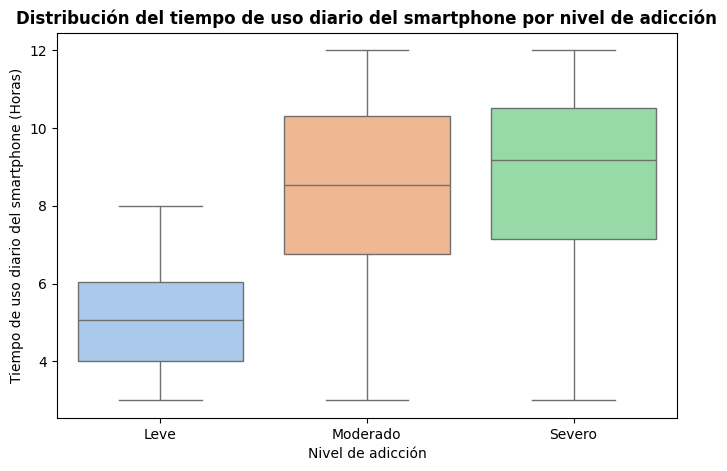

In [139]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Nivel de adicción",y="Tiempo de uso diario del smartphone (Horas)", data=df,palette="pastel")
plt.title("Distribución del tiempo de uso diario del smartphone por nivel de adicción", fontweight="bold")
plt.show()

Se identifica que de acuerdo al tiempo de uso del teléfono se clasifica el nivel de adicción en dos categorías: leve y moderado/severo.

##### **Tiempo de uso diario del smartphone vs edad:**

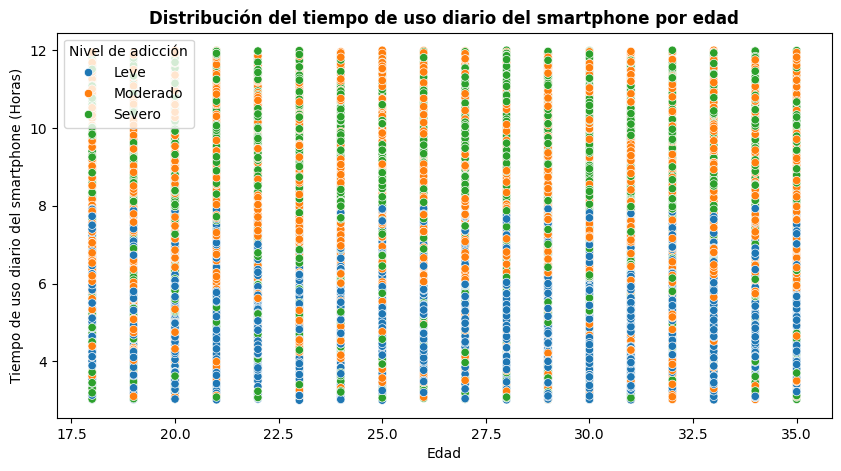

In [140]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Edad",y="Tiempo de uso diario del smartphone (Horas)", hue="Nivel de adicción", data=df)
plt.title("Distribución del tiempo de uso diario del smartphone por edad", fontweight="bold")
plt.show()

Se identifica que para cada uno de los intervalos de edad se presentan las tres categóricas del nivel de adicción: leve, moderado y severo.

#####**Tiempo de uso diario del smartphone vs género:**

/tmp/ipykernel_17884/4064240367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Género",y="Tiempo de uso diario del smartphone (Horas)", palette="pastel", data=df)


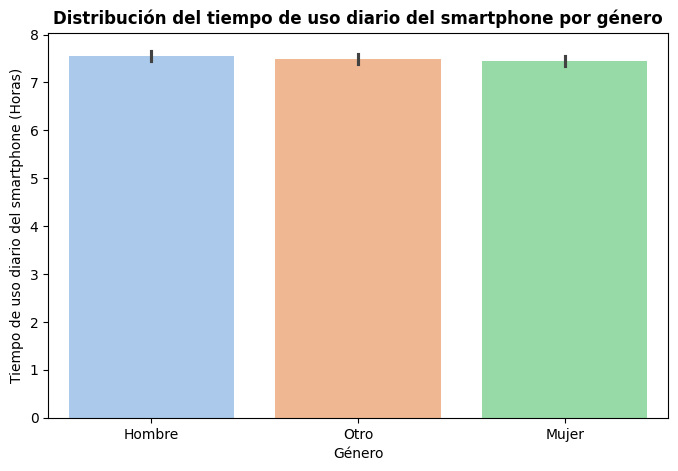

In [141]:
plt.figure(figsize=(8,5))
sns.barplot(x="Género",y="Tiempo de uso diario del smartphone (Horas)", palette="pastel", data=df)
plt.title("Distribución del tiempo de uso diario del smartphone por género", fontweight="bold")
plt.show()

Se identifica que el tiempo de uso diario del teléfono se distribuye de manera equitativa en el género.

##### **Tiempo usado en videojuegos vs género:**

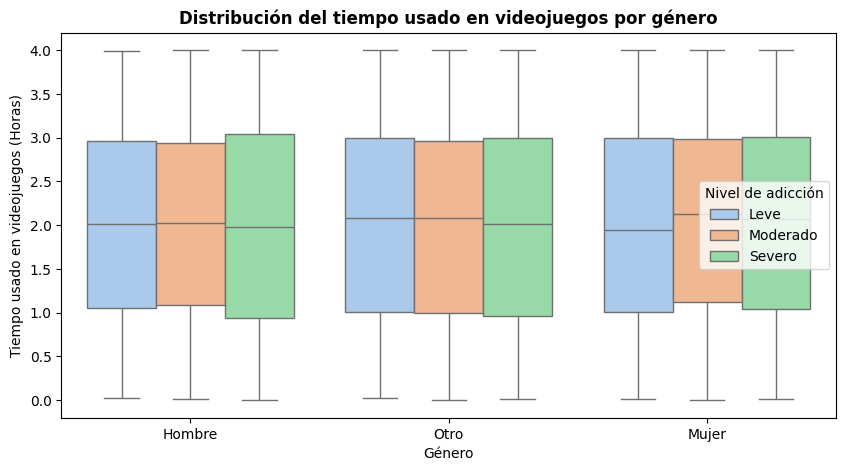

In [142]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Género",y="Tiempo usado en videojuegos (Horas)", hue="Nivel de adicción", data=df, palette="pastel")
plt.title("Distribución del tiempo usado en videojuegos por género", fontweight="bold")
plt.show()

El gráfico permite determinar que el tiempo usado en videojuegos es similar de manera indiferente al género, y no se muestra una relación de influencia o determinante para categorizar por el nivel de adicción.

##### **Tiempo usado en videojuegos vs impacto sobre el rendimiento académico o laboral:**

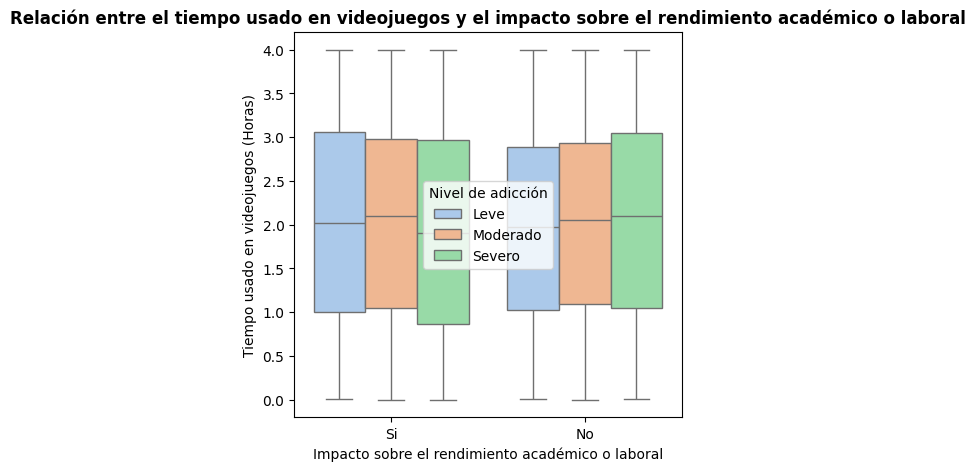

In [143]:
plt.figure(figsize=(5,5))
sns.boxplot(x="Impacto sobre el rendimiento académico o laboral",y="Tiempo usado en videojuegos (Horas)",hue="Nivel de adicción", data=df, palette="pastel")
plt.title("Relación entre el tiempo usado en videojuegos y el impacto sobre el rendimiento académico o laboral", fontweight="bold")
plt.show()

El gráfico permite evidenciar que el tiempo usado en videojuegos en los individuos no influye en el impacto sobre el rendimiento académico o laboral, mostrando homogeneidad y que no son variables clasificatorias claves sobre el nivel de adicción.


##### **Nivel de estrés vs número de notificaciones por día recibidas en el celular:**


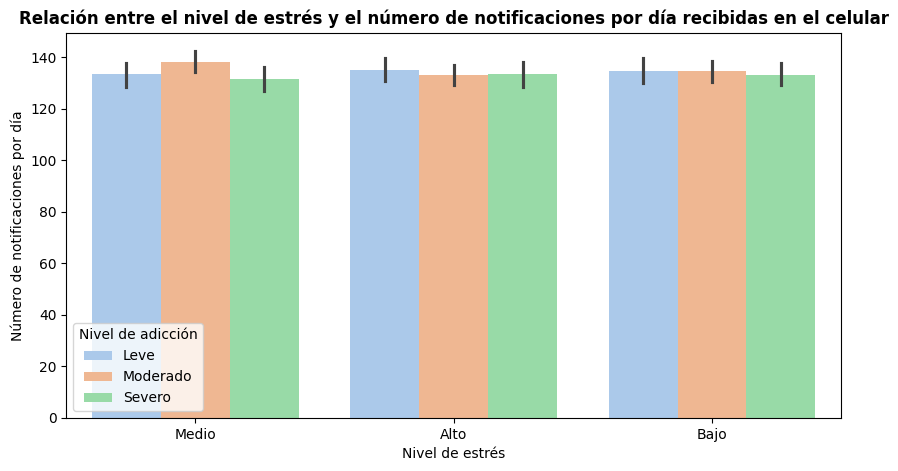

In [144]:
plt.figure(figsize=(10,5))
sns.barplot(x="Nivel de estrés",y="Número de notificaciones por día", hue="Nivel de adicción", palette="pastel", data=df)
plt.title("Relación entre el nivel de estrés y el número de notificaciones por día recibidas en el celular", fontweight="bold")
plt.show()

El gráfico permite evidenciar que el nivel de estrés no está determinado o influido por el número de notificaciones recibidas por día como se podría inferir antes de la investigación.

##### **Tiempo de uso de redes sociales y tiempo de uso diario del smartphone:**

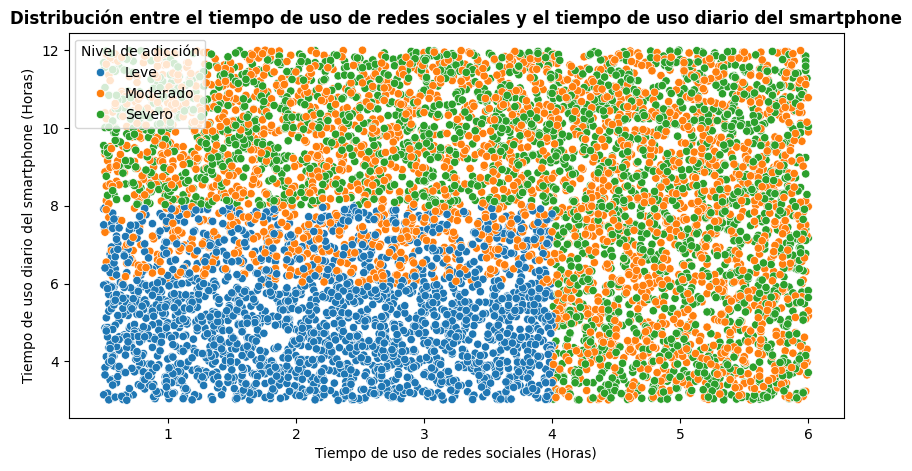

In [145]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Tiempo de uso de redes sociales (Horas)",y="Tiempo de uso diario del smartphone (Horas)", hue="Nivel de adicción", data=df)
plt.title("Distribución entre el tiempo de uso de redes sociales y el tiempo de uso diario del smartphone", fontweight="bold")
plt.show()

Se evidencia un patrón donde el nivel de adicción leve se caracteriza por tiempo de uso diario del smartphone de 0 hasta 8 horas y un tiempo en redes sociales de 0 a 4 horas.
En segundo lugar, el nivel de adicción incrementa a moderado si el individuo presenta un tiempo de uso diario entre 6 y 12 horas y tiempo en redes sociales entre 4 y 6 horas.
Y en tercer lugar el nivel de adicción severo se presenta únicamente cuando el tiempo de uso diario es de 8 horas hasta 12 horas y el tiempo en redes sociales es de 4 a  6 horas.
Esta gráfica muestra la estrecha relación entre índice de adicción y el tiempo destinado para redes sociales, así como la relación entre índice de adicción y el tiempo de uso diario del smartphone especialmente para separar los niveles leves de los severos.


##### **Horas de suelo y tiempo de uso  y tiempo de uso diario del smartphone:**

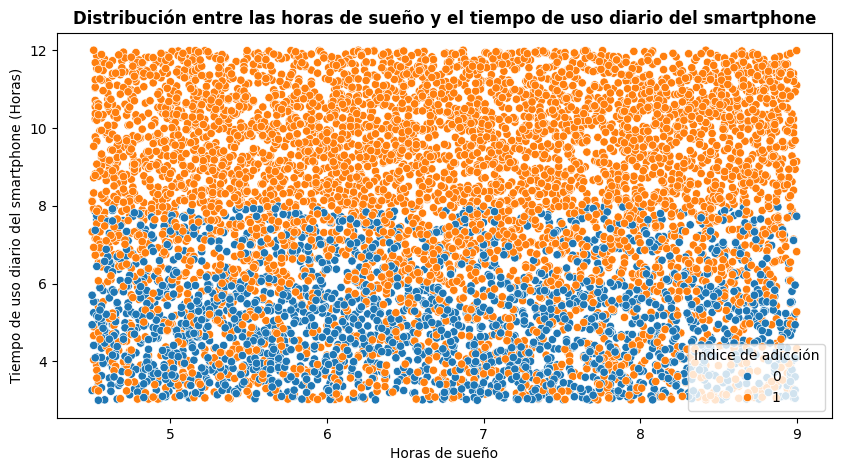

In [146]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Horas de sueño",y="Tiempo de uso diario del smartphone (Horas)", hue="Indice de adicción", data=df)
plt.title("Distribución entre las horas de sueño y el tiempo de uso diario del smartphone", fontweight="bold")
plt.show()

La gráfica refleja como las horas de sueño no influyen en la determinación o categorización del índice de adicción. Sin embargo, el tiempo de uso diario del smartphone si es una variable influyente que distingue el nivel leve con tiempo de uso diario de 0 a 8 horas. Sin embargo, el nivel 1 (moderado o severo) puede abarcar una zona más amplia de 0 hasta 12 horas.

##### **Conclusiones generales del análisis exploratorio de datos:**
*   se realizó el proceso de validación, limpieza y tratamiento de los datos que incluyó determinación de registros duplicados, tratamiento de valores nulos, escalamiento de variables y detección de valores nulos.
*   Se identificó que las mayoria de variables son uniformes. Las variables de mayor influencia en la determinación o clasificación del nivel de adicción son el tiempo de uso diario del smartphone, el tiempo usado en videojuegos y el tiempo usado los fines de semana. Las demás variables como la edad, el género, las horas de sueño o el nivel de estrés presentan baja influencia en la clasificación de los individuos por nivel de adicción.




## **Paso 7: Aplicación de modelos de regresión lineal múltiple:**

#### **Definición de variables independientes y dependientes con base en la correlación de pearson:**
La variable dependiente a predecir (Y) es la variable indice de adicción, la cual, es una variable binaria sin embargo se podrá utilizar para este ejercicio práctico.

Por otra parte, las variables predictorias seleccionadas con base en el coeficiente de correlación de Pearson (Ver sección 6.1) son:
* Tiempo de uso diario del smartphone (Horas)
* Tiempo de uso de redes sociales (Horas)


No se integrara la varible Tiempo en pantalla los fines de semana debido a que puede ser redundante con la variable Tiempo de uso diario del smartphone (Horas)

In [147]:
variables_numericas

['Edad',
 'Tiempo de uso diario del smartphone (Horas)',
 'Tiempo de uso de redes sociales (Horas)',
 'Tiempo usado en videojuegos (Horas)',
 'Tiempo destinado a trabajo o estudio (Horas)',
 'Horas de sueño',
 'Número de notificaciones por día',
 'Número de veces que abre aplicaciones al día',
 'Tiempo en pantalla los fines de semana',
 'Indice de adicción']

In [148]:
variables_predictorias= [
     'Tiempo de uso diario del smartphone (Horas)',
     'Tiempo de uso de redes sociales (Horas)']

In [149]:
variable_dependiente='Indice de adicción'

In [150]:
x=df[variables_predictorias]
y=df[variable_dependiente]

### **7.1 Regresión lineal multiple:**

#### ***7.1.1 Regresión lineal como función explicativa (sin dividir en datos de entrenamiento y de prueba):***

In [151]:
modelo=LinearRegression()
modelo.fit(x,y)

coeficientes=modelo.coef_
intercepto=modelo.intercept_
print("Coeficientes:",coeficientes)
print("Intercepto:",intercepto)

Coeficientes: [0.09986773 0.11715017]
Intercepto: -0.42475502491515815


Bajo un función explicativa utilizada para describir un modelo que muestra el comportamiento de "Y" bajo los parametros "X", es decir sin dividir por datos de entrenamiento y de prueba" sino simplemente generando una función matematica que explique la relación observamos una ecuación que nos indica lo siguiente:


*   Si no existiera un consumo diario de horas en el smartphone, en redes sociales o el fin de semana, obtendriamos un índice de adicción de -0.4 (intercepto), el cual se encuentra por debajo de rango de clasificación del indice de adicción (de 0 a 1)




In [152]:
# Con base en el modelo se calculan las predicciones para la variable Y
y_pred=modelo.predict(x)

#Cálculo de métrias
mse=mean_squared_error(y,y_pred)
rmse=mse**0.5
mae=mean_absolute_error(y,y_pred)
r2=r2_score(y,y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

MSE: 0.10347001640373632
RMSE: 0.32166755572133215
MAE: 0.27170234349341055
R2: 0.4997747836630213


* El modelo explica el 49.9% de la variabilidad observada en Y.
* La metricas MSE, RMSE y MAE referentes al error se muestran bajas, sin embargo,  esta variable se puede comparar con los resultados de metricas de otros modelos .

#### **7.1.2 Regresión lineal multiple con función predictiva (con datos de entrenamiento y prueba):**



> #### ***7.1.2.1 Dividir los datos para entrenamiento (Train) y para evaluar (test):***



In [153]:
#Divido los datos: 70% de entrenamiento, 30% de prueba
x_train, x_test,y_train, y_test = train_test_split(x,y,
                                                   test_size=0.30,
                                                   random_state=0)

In [154]:
x.shape, y.shape #Tamaño original

((7500, 2), (7500,))

In [155]:
x_train.shape, x_test.shape,y_train.shape,y_test.shape

((5250, 2), (2250, 2), (5250,), (2250,))

> #### ***7.1.2.2 Estandarización de variables independientes de entrenamiento (x_train) y de prueba (x_test) mediante Z-Score:***



Para el proceso de estandarización únicamente entrenare el modelo con los los datos de entrenamiento de las variables independientes (no los de prueba), de esta forma, el modelo no aprendera ni conocera aún de los datos de prueba.

In [156]:
#Estandarizo los datos de entrenamiento y prueba de variables independientes
scaler=StandardScaler()
scaler.fit(x_train) #Entreno el modelo con los datos de entrenamiento de variables independientes
x_train_scaled=scaler.transform(x_train) # Estandarizo los datos de entrenamiento
x_test_scaled=scaler.transform(x_test) #Estandarizo los datos de prueba

> #### ***7.1.2.3 Ajusto el modelo de regresión con variables estandarizadas***


In [157]:
modelo_estandarizado = LinearRegression()
modelo_estandarizado.fit(x_train_scaled,y_train)

coef_modelo_estandarizado = modelo_estandarizado.coef_ #Extraigo coeficientes
intercepto_modelo_estandarizado = modelo_estandarizado.intercept_ #Extraigo intercepto

print(f"Coeficientes: {coef_modelo_estandarizado}")
print(f"Intercepto: {intercepto_modelo_estandarizado}")



Coeficientes: [0.25725928 0.18864611]
Intercepto: 0.7068571428571427


Indice = 0.707 + 0.257(Tiempo de uso diario del smartphone) + 0.189 (Tiempo de uso en redes sociales)

In [158]:
coeficientes_modelo_estandarizado= pd.DataFrame([[intercepto_modelo_estandarizado]+list(coef_modelo_estandarizado)],
                                                columns=["B0","B1","B2"],
                                                index=["Coeficientes modelo estandarizado"])
coeficientes_modelo_estandarizado

,B0,B1,B2
Coeficientes modelo estandarizado,0.706857,0.257259,0.188646


El modelo de regresión con datos estandarizados nos indica que:

* Coeficiente de Tiempo de uso diario del smartphone (Horas), nos indica que el aumento de 1 desviación estandar se asocia a un incremento promedio de 0.257 unidades en el indice de adicción
* El coeficiente del Tiempo de uso de redes sociales (Horas) indica que con el aumento de 1 desviación estandar de esta variable aumenta en 0.189 unidades el indice de adicción.


La variable con mayor influencia es el tiempo de uso diario del smartphone en el indice de adicción.

> #### ***7.1.2.4 Evaluación del modelo lineal multiple estandarizado:***


In [159]:
# Calculo las predicciones de "Y" de los datos entrenados
y_pred_train_me = modelo_estandarizado.predict(x_train_scaled)

#Comparación entre resultados de Y_train y el predecido Y_train_predicted
mse_train_me=mean_squared_error(y_train,y_pred_train_me) # Calculo del la medida del error promedio al cuadrado
rmse_train_me = mse_train_me**0.5
mae_train_me= mean_absolute_error(y_train,y_pred_train_me) #Calculo del error absoluto medio
r2_train_me = r2_score(y_train,y_pred_train_me) #Determinación del coeficiente de determinación

print(f"MSE: {mse_train_me}")
print(f"RMSE: {rmse_train_me}")
print(f"MAE: {mae_train_me}")
print(f"R2: {r2_train_me}")


MSE: 0.10432013359007565
RMSE: 0.3229862746156184
MAE: 0.2731508417579926
R2: 0.4965490471356585


La raiz del error cuadrático medio indica que el modelo se equivoca en 0.32 horas (19 minutos) de la observación de acuerdo al RMSE.
Mientras que el coeficiente de determinación indica que el modelo puede explicar el 49.7% de la variabililidad de la variable indice de adicción, el cual no es muy alto ni muy bajo.

In [160]:
# Calculo las predicciones de "Y" de los datos entrenados
y_pred_test_me = modelo_estandarizado.predict(x_test_scaled)

#Comparación entre resultados de Y_train y el predecido Y_train_predicted
mse_test_me=mean_squared_error(y_test,y_pred_test_me) # Calculo del la medida del error promedio al cuadrado
rmse_test_me = mse_test_me**0.5
mae_test_me= mean_absolute_error(y_test,y_pred_test_me)
r2_test_me = r2_score(y_test,y_pred_test_me) #Determinación del coeficiente de determinación

print(f"MSE: {mse_test_me}")
print(f"RMSE: {rmse_test_me}")
print(f"MAE: {mae_test_me}")
print(f"R2: {r2_test_me}")


MSE: 0.1015553598602136
RMSE: 0.3186775170296982
MAE: 0.26878732335644934
R2: 0.506996743230913


La raiz del error cuadrádito medio indica que el modelo se equivoca en 0.318 horas (19 minutos) de acuerdo al RMSE y el coeficiente de determinación muestra que se explica el 50.7% de la variabilidad de los datos de la variable indice de adicción.

En los datos de prueba se observa un aumento en el coeficiente de determinación y una disminución en las metricas de error (MSE, RMSE y MAE)

**Análisis de manera global:**
Se evidencia similitud entre las metricas de entrenamiento y prueba, lo que permite evidenciar que el modelo generaliza de manera estable (no hay sobreajuste), sin embargo, aun explica una variabilidad de la variable dependiente moderado.

Se puede aplicar técnicas como regularización y validación cruzada para mejorar el ajuste y predicción.

## ***Paso 8: Validación del cumplimiento de supuestos:***




Despues de que se ajustara el modelo con los datos de entrenamiento, es importante verificar si cumple los supuestos.

La validación de supuestos es un proceso que verifica que las condiciones subyacentes a un modelo estadístico se cumplen con los datos reales. De manera que asegura que los resultados son fiables y no fruto del azar.

### ***8.1 Diagnóstico estadístico mediante el modelo Ordinary Least Squares - OLS (Mínimos cuadrados ordinarios) de la libreria statsmodels:***


Realiza una regresión lineal global de Mínimos cuadrados ordinarios (OLS) para generar una predicción o modelar una variable dependiente en términos de sus relaciones con un conjunto de variables explicativas. Sin embargo, a diferencia de sklearn, OLS permite obtener parámetros para la validación de supuestos que la primera libreria no permite.

In [161]:
X = x_train_scaled #Se entrenó con los mismos datos utilizados para entrenar el modelo de SK-Learn
y = y_train

X = sm.add_constant(X)

model_sm = sm.OLS(y, X).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:     Indice de adicción   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     2588.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        12:53:45   Log-Likelihood:                -1516.2
No. Observations:                5250   AIC:                             3038.
Df Residuals:                    5247   BIC:                             3058.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7069      0.004    158.527      0.0

Se observa que los coeficientes  e interceptos son similares al de sklearn.

Con el resumen del modelo estadistico podemos observar:
* El coeficiente de determinación no muy alto (49.7%). El coeficiente de correlación y el coeficiente ajustado tan cercanos indica que no hay sobreajuste.
* La probabilidad F-Statistic = 0, lo que indica que el modelo de manera global explica los valores de Indice de adicción.
* Los coeficientes de las variables y el intercepto son positivos.
* Los P>|t| < 0.05 indican que las dos variables aporta mucho al modelo.
* Los intervalos 0.025 a 0.975 indican que las dos variables son relevantes al no incluir el cero.
* La autocorrelación por Derbin Watson ~2 muestra que  no existe autocorrelación de residuos.
* El condition number (Cond No.) con un valor pequeño indica muy baja multicolinealidad.


### ***8.2 Obtención de residuos:***


In [162]:
residuos = y_train - y_pred_train_me

### ***8.3 Normalidad:***

El supuesto indica que los residuos se distribuyen normalmente.Se aplico el método visual mediante QQ-plot de residuos y el método estadístico Shapiro-Wilk.

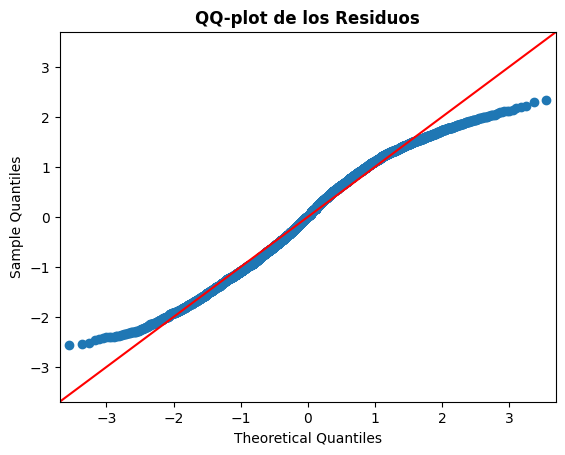

In [163]:
smt.qqplot(residuos, line='45', fit=True)
plt.title('QQ-plot de los Residuos', fontweight="bold")
plt.show()

**Forma de interpretación:** En el gráfico QQ-PLOT, los cuantiles de la muestra se comparan con los cuantiles teóricos de la distribución de interés. Si los puntos en el gráfico se ajustan aproximadamente a una línea diagonal, indica que los datos siguen de cerca la distribución teórica (normal)

**Resultados:** Al observar los puntos no se alinean de forma recta sobre la linea, rechazando comportamiento de distribución normal de los residuos.

In [164]:
shapiro(residuos)



/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5250.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9833042576766043), pvalue=np.float64(2.0091581805800343e-24))

Bajo las hipotesis:

Ho: Los residuos tienen distribución normal

Ha: Los residuos no siguen una distribución normal

y con un p-value bajo, se rechaza la hipotesis nula. Por lo cual, los residuos no presentan distribución normal.

### ***8.4 Homocedasticidad:***

La homocedasticidad evalúa si los residuos tienen varianza constante a lo largo de las predicciones del modelo.
Las hipotesis plantean:

Ho: Existe homocedasticidad

Ha: No existe homocedasticidad

Para evaluar homocedasticidad se utilizó el método gráfico y la  prueba de Breusch–Pagan test.

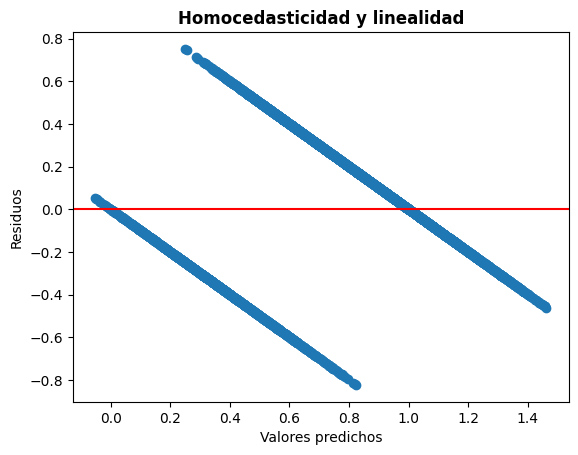

In [165]:
plt.scatter(y_pred_train_me, residuos)
plt.axhline(0, color='red')

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Homocedasticidad y linealidad",fontweight="bold")

plt.show()


**Forma de interpretar:**  Lo que se espera es observar un patrón aleatorio alrededor de 0. Un patrón aleatorio sugiere que el modelo de regresión es apropiado y que los supuestos del modelo se cumplen.

**Resultados:** Se observa dos líneas diagonales paralelas con pendiente negativa. Esta visualizacion es común cuando la variable dependiente es limitada, como en este caso que es binaria.

In [166]:
bp_test = het_breuschpagan(model_sm.resid, model_sm.model.exog)

print("LM Statistic:", bp_test[0])
print("p-value:", bp_test[1])




LM Statistic: 613.8619352791808
p-value: 5.03007463317916e-134


El pvalue de Breusch-Pagan al ser tan bajo rechaza la hipotesis nula, y por lo tanto, los residuos no cumplen el supuesto de homocedasticidad.

### **8.5 Linealidad:**

El supuesto de linealidad afirma que la relación entre las variables predictoras X y la variable objetivo Y debe poder representarse de manera lineal.

Al observar el gráfico de residuos vs valores predichos se debería observar que los residuos deben estar aleatoriamente dispersos alrededor de la línea horizontal en cero.

Sin embargo, como se afirmo anteriormente, se observan lineas diagonales con pendiente negativa, los cuales son comunes de observar cuando la variable dependiente es binaria y no es continua.

Por otro lado, se puede utitlizar el Rainbow test, el cual plantea las hipotesis:

Ho: Es lineal

Ha: no es lineal

In [167]:
stat, p_value = linear_rainbow(model_sm)
print(f"p-valor: {p_value}")

p-valor: 0.5476828228094384


Mediante el Rainbow test se obtiene que el modelo no es lineal.

### **8.6 Independencia:**

El supuesto de independencia indica que los residuos del modelo no deben estar correlacionados entre sí.

Para evaluar la independencia de los residuos se utiliza la prueba Durbin–Watson según la cual:
* d similar a 2: Indica que no hay autocorrelación (se cumple el supuesto).
* Entre 0 y 2: Indica autocorrelación positiva
* Entre 2 y 4: Indica autocorrelación negativa (los valores vecinos son muy diferentes entre sí).

In [168]:
durbin_watson(residuos)

np.float64(2.0211323332597466)

Dado que la autocorrelación es cercana a 2 indica que no hay autocorrelación entre residuos, lo que indica que  son independientes.

### ***8.7 Multicolinealidad:***

El supuesto de no multicolinealidad establece que las variables independientes no deben estar altamente correlacionadas entre sí. Se utiliza el Factor de Inflación de la Varianza (VIF).

Se interpreta de la siguiente forma:
* VIF = 1: Sin correlación.

* VIF entre 1 y 5: Correlación moderada

* VIF > 5 o 10: Multicolinealidad severa lo cual indica que se debe eliminar variables que son redundantes con otras.

In [169]:
x_train_scaled_df = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns)

In [170]:
vif = pd.DataFrame()
vif["Variable"] = x_train_scaled_df.columns
vif["VIF"] = [
    variance_inflation_factor(x_train_scaled_df.values, i)
    for i in range(x_train_scaled_df.shape[1])
]

vif

,Variable,VIF
0,Tiempo de uso diario del smartphone (Horas),1.000133
1,Tiempo de uso de redes sociales (Horas),1.000133


Muestra que las variables Tiempo de uso diario del smartphone y Tempo de uso de redes sociales (Horas) no son redundantes entre si y por lo tanto no hay multicolinealidad.

### ***8.8 Diagnóstico de influencia:***

La distancia de cook es una herramienta que se utiliza para identificar valores influyentes en un modelo de regresión. A diferencia de un valor atípico (outlier), que es simplemente un punto alejado de los demás, un punto influyente es aquel que tiene tanto peso que, si se elimina, los coeficientes del modelo cambian drásticamente.

In [171]:
influence = model_sm.get_influence()
cooks = influence.cooks_distance[0]

# identificar observaciones con alta influencia (regla práctica: > 4/n)
n = len(x_train_scaled)
threshold = 4/n
influential_points = np.where(cooks > threshold)[0]
print("Número observaciones influyentes:", len(influential_points))

Número observaciones influyentes: 90


En este caso se han identificado 90 posibles datos como influyentes, vamos a realizar una comparación entre el modelo con datos completos y el modelo eliminando estos datos, para verificar su importancia.

#### **8.8.1 Creación y ajuste de modelos con influyentes y sin influyentes:**

**Modelo A:** Con todos los datos de entrenamiento

In [172]:
modelo_A = LinearRegression()
modelo_A.fit(x_train_scaled, y_train)

y_pred_A_train = modelo_A.predict(x_train_scaled)

**Modelo B:** Modelo sin los datos influyentes

In [173]:
#Eliminamos de los datos entrenados los puntos influyentes antes de entrenar el modelo, y así comparar resultados posteriormente
x_train_B = np.delete(x_train_scaled,
                      influential_points,
                      axis=0)
y_train_B = np.delete(y_train,
                      influential_points)

#Creación y ajuste del modelo B
modelo_B = LinearRegression()
modelo_B.fit(x_train_B, y_train_B)

y_pred_B_train = modelo_B.predict(x_train_B)

#### **8.8.2 Evaluación de Modelo A vs Modelo B:**

In [174]:
def metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse**0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

mse_A, rmse_A, mae_A, r2_A = metricas(y_train, y_pred_A_train)
mse_B, rmse_B, mae_B, r2_B = metricas(y_train_B, y_pred_B_train)


In [175]:
print(f"Modelo A (con influyentes):  β1 y β2 = {modelo_A.coef_},  β0 = {modelo_A.intercept_}")

Modelo A (con influyentes):  β1 y β2 = [0.25725928 0.18864611],  β0 = 0.7068571428571427


In [176]:
print(f"Modelo B (sin influyentes):  β1 y β2 = {modelo_B.coef_},  β0 = {modelo_B.intercept_}")

Modelo B (sin influyentes):  β1 y β2 = [0.26913332 0.19070849],  β0 = 0.6977135722632468


In [177]:
comparacion_coeficientes=pd.DataFrame([[modelo_A.intercept_]+[modelo_B.intercept_],
                                      [modelo_A.coef_[0]]+ [modelo_B.coef_[0]],
                                      [modelo_A.coef_[1]] +[modelo_B.coef_[1]]],
                                      columns=["Modelo A (Con influyentes)","Modelo B (Sin influyentes)"],
                                      index=["β0","β1","β2" ])
comparacion_coeficientes

,Modelo A (Con influyentes),Modelo B (Sin influyentes)
β0,0.706857,0.697714
β1,0.257259,0.269133
β2,0.188646,0.190708


* **Intercepto (B0):** El intercepto en el modelo B disminuye muy levemente, y su dirección continua siendo positiva

* **B1:** El coeficiente de la primera variable aumenta levemente y continua siendo positivo.


* **B2:** El coeficiente de la segunda variable aumenta levemente y continua siendo positivo.

Los cambios entre el modelo con datos influyentes y sin los datos influyentes cambian muy poco, por lo cual se puede inferir que no distorsionan en gran medida el modelo.

In [178]:
metricas_modelo_comparativo=pd.DataFrame([[mse_A]+[mse_B],
                                         [rmse_A]+[rmse_B],
                                         [mae_A]+[mae_B],
                                         [r2_A]+[r2_B]],
                                         index=["MSE","RMSE","MAE","R2"],
                                         columns=["Modelo A (Con influyentes)","Modelo B (Sin influyentes)"])
metricas_modelo_comparativo

,Modelo A (Con influyentes),Modelo B (Sin influyentes)
MSE,0.104320,0.099876
RMSE,0.322986,0.316032
MAE,0.273151,0.266885
R2,0.496549,0.522807


Se observa un mayor coeficiente de determinación en el modelo B y menor medida de error (MSE, RMSE y MAE) en el modelo B.

De manera que se  construira el modelo y se aplicará regresión regularizada con base en este modelo B sin datos influyentes.

#### **8.8.3 Aplicación de validación cruzada por KFold con los datos de entrenamiento del Modelo B:**



De acuerdo con Attal (2026), la técnica de KFold permite garantizar que todas las observaciones de la serie de datos original tenga la oportunidad de aparecer en la serie de entrenamiento y en la de prueba.
El procedimiento que sigue el algoritmo es el siguiente:
1. El algoritmo mezcla de manera aleatoria el conjunto de datos.
2. Separa la serie de datos de manera aleatoria en "K" subconjuntos de igual tamaño llamados "folds". El parametro K hace referencia al número de grupos en el que se dividirá la muestra, por lo general es entre 5 y 10.
3. El algoritmo selecciona uno de los subconjuntos como datos de prueba, y utiliza los demás subconjuntos (k-1) para entrenar el modelo.  Se realiza el calculo de metricas evaluando el modelo con el subconjunto de prueba.
4. El algoritmo repite el paso 3 reiterativamente cambiando el conjunto de prueba en cada iteracción.
5. El desempeño final del modelo es el promedio de los desempeño de cada una de las k-interacciones.

In [179]:
#Recordemos como se llama nuestro modelo entrenado con variables independientes estandarizadas y sin valores influyentes:
  #Nombre del modelo: modelo_B
  #Con x_train_B y y_train_b


#Validación cruzada K-Fold
k = 5
modelo_k_fold = KFold(n_splits=k,shuffle=True,random_state=0) #Con shuffle=True se mezclan los datos aleatoriamente antes de dividirlo

mse_cv_B= -cross_val_score(modelo_B,x_train_B,y_train_B,
                         scoring="neg_mean_squared_error", #metrica para evaluar el modelo
                         cv=modelo_k_fold) #cv indica los parametros para cross-validation

rmse_cv_B=-cross_val_score(modelo_B,x_train_B,y_train_B,
                      scoring="neg_root_mean_squared_error",
                      cv=modelo_k_fold)

mae_cv_B= -cross_val_score(modelo_B,x_train_B,y_train_B,
                      scoring="neg_mean_absolute_error",
                      cv=modelo_k_fold)

r2_cv_B=cross_val_score(modelo_B,x_train_B,y_train_B,
                      scoring="r2",
                      cv=modelo_k_fold)

mse_cv_B_mean=mse_cv_B.mean()
rmse_cv_B_mean=rmse_cv_B.mean()
mae_cv_B_mean=mae_cv_B.mean()
r2_cv_B_mean=r2_cv_B.mean()



In [180]:
#Tabla comparativa de las metricas para cada uno de los resultados por cada Fold
tabla_resultados_cv=pd.DataFrame([
    list(mse_cv_B) + [mse_cv_B_mean],
    list(rmse_cv_B) + [rmse_cv_B_mean],
    list(mae_cv_B) + [mae_cv_B_mean],
    list(r2_cv_B) + [r2_cv_B_mean]],
    index=["MSE", "RMSE","MAE", "R2"],
    columns=[
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5",
        "Promedio"])
tabla_resultados_cv

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Promedio
MSE,0.106569,0.098611,0.096191,0.101457,0.097009,0.099967
RMSE,0.326449,0.314024,0.310147,0.318524,0.311462,0.316121
MAE,0.276829,0.265743,0.262423,0.268739,0.261161,0.266979
R2,0.511624,0.522691,0.537979,0.520721,0.516795,0.521962


Mediante validación cruzada es posible identificar:

* **r2:** El modelo explica desde el 52% en promedio de la variabilidad en los datos del indice de adicción, lo cual es moderado. Se observa estabilidad porque los r2 no difieren de una manera muy significativa. Este valor es moderado y se considera esperado teniendo en cuenta que el supuesto de linealidad no se cumplió (Sección 8.5).

* **RMSE:** El modelo se equivoca en promedio ±0.32 horas, es decir (19 minutos) lo cual es un corto tiempo al dia para definir o no adicción. También se observa que el modelo es estable porque los valores de evaluación de RMSE en cada fold no difieren en gran medida y por lo tanto es robusto (no tiene cambios drasticos ante cambios pequeños).

* **MSE:** Se observa como la medida de error promedio difiere en cada fold de manera leve

* **MAE:** Se observan cambios ligeramente leves.


**Generalidades:** Se evidencia que el modelo es estable para predecir a partir de subconjuntos de los datos de entrenamiento de manera iterativa.


#### **8.8.4 Validación de supuestos en el modelo B:**

In [181]:
residuos_B = y_train_B - y_pred_B_train

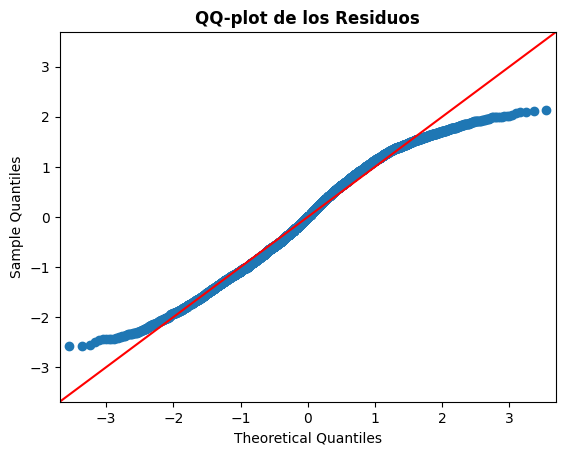

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5160.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9826118297305945), pvalue=np.float64(1.0752273381295524e-24))

In [182]:
#Normalidad
smt.qqplot(residuos_B, line='45', fit=True)
plt.title('QQ-plot de los Residuos', fontweight="bold")
plt.show()
shapiro(residuos_B)

Los residuos del modelo B rechazan la hipotesis nula, no siguen una distribución normal.

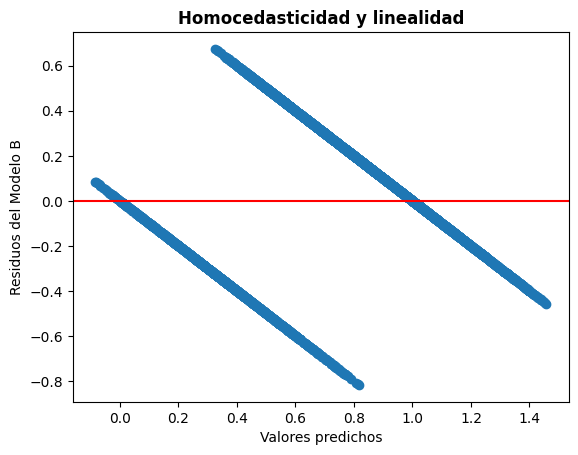

LM Statistic: 475.30296421028703
p-value: 6.155632807155839e-104


In [183]:
#Homocedasticidad
plt.scatter(y_pred_B_train, residuos_B)
plt.axhline(0, color='red')

plt.xlabel("Valores predichos")
plt.ylabel("Residuos del Modelo B")
plt.title("Homocedasticidad y linealidad",fontweight="bold")
plt.show()


#OLS del Modelo B
X_B = x_train_B #Se entrenó con los mismos datos utilizados para entrenar el modelo de SK-Learn
y_B = y_train_B

X_B = sm.add_constant(X_B)
model_sm_B = sm.OLS(y_B, X_B).fit()

#breuschpagan test
bp_test = het_breuschpagan(model_sm_B.resid, model_sm_B.model.exog)

print("LM Statistic:", bp_test[0])
print("p-value:", bp_test[1])

Con un p-value tan pequeño, los residuos del modelo B rechazan el supuesto de homocedasticidad.

In [184]:
#Linealidad
stat, p_value = linear_rainbow(model_sm_B)
print(f"p-valor: {p_value}")

p-valor: 0.6192949328122319


Con un p_value de 0.6 se acepta linealidad en los residuos del modelo B.

In [185]:
#Independencia
durbin_watson(residuos_B)

np.float64(2.0233939305264457)

Con un resultado de Durbin Watson Test de 2 se acepta independencia en los residuos

In [186]:
# Multicolinealidad


X_vif_B = pd.DataFrame(x_train_B, columns=x_train.columns)

vif_B = pd.DataFrame()

vif_B["Variable"] = X_vif_B.columns

vif_B["VIF"] = [
    variance_inflation_factor(X_vif_B.values, i)
    for i in range(X_vif_B.shape[1])]

print(vif_B)

                                      Variable       VIF
0  Tiempo de uso diario del smartphone (Horas)  1.000422
1      Tiempo de uso de redes sociales (Horas)  1.000422


El VIF == 1 indica que las variables no son redundantes entre si.

## ***Paso 9. Regresión regularizada de Ridge y Lasso con validación cruzada:***



Para aplicar la regresión regularizada de Ridge y Lasso se realizara con validación cruzada.

Importante recordar que la validación cruzada, la regresión regularizada (lasso y Ridge) se realizan con los datos de entrenamiento ya que hace parte de la construcción y evaluación interna del modelo antes de evaluarlos con los datos de prueba.




### ***9.2 Regresión regularizada Ridge con validación cruzada:***




Se aplican técnicas de regularización, las cuales, se aplican en Machine Learning para prevenir el sobreajuste y mejorar la capacidad de generalización de los modelos.
Busca que sea más simple y evite memorizar el ruido de los datos, de esta forma, se generaliza mejor.


De acuerdo con IBM (s.f) la regresión de Ridge (también conocida como regularización L2)  es una de las técnicas de regularización que se utiliza en regresión lineal que permite:
* Gestionar la multinolinealidad, es decir, gestionan problemas cuando las variables predictorias son altamente correlacionables entre si. Cuando las variables está muy correlacionadas, los coeficientes suelen ser muy altos.
* Previene el sobreajuste

Lo que hace la regularización de Ridge es  corregir los coeficientes de alto valor introduciendo un término de regularización (llamado penalización), el cual es la suma de los cuadrados de los coeficientes del modelo, la cual se inserta al final de la función de RSS (la suma residual de los cuadrados), el efecto esta controlado por el parámetro lamda (λ), el cual puede tomar valores desde 0 hasta  +infinito.

Suma de residuos cuadrados + λ*suma de las pendientes al cuadrado

  * El término de penalización L2 lo que hace es contrarrestar los ecoeficientes especialmente alto al disminuir todos los valores de los coeficientes (llamado reducción del coeficiente) en proporción a su tamaño inicial, reduciento el efecto de cada predictor (variables x) y reduce el sobreajuste en los datos.
    * A medida que lambda aumenta, los coeficientes de alto valor se reducen a un ritmo mayor que los coeficientes de valor bajo.

    * La penalización L2 nunca lleva a los coeficientes a 0.

In [187]:
#En sklearn el parametro de regularización se llama alpha

alphas = [0.01, 0.1, 1, 10, 100]

resultados_ridge = []

for a in alphas:
    ridge = Ridge(alpha=a) #Probamos diferentes alphas
    mse_ridge_cv_mean = -cross_val_score(ridge, x_train_B, y_train_B,  #Se utilizan los datos del modelo B
                              scoring="neg_mean_squared_error",
                              cv=modelo_k_fold).mean()


    rmse_ridge_cv_mean= -cross_val_score(ridge,x_train_B,y_train_B,
                                    scoring="neg_root_mean_squared_error",
                                    cv=modelo_k_fold).mean()

    mae_ridge_cv_mean= -cross_val_score(ridge,x_train_B,y_train_B,
                      scoring="neg_mean_absolute_error",
                      cv=modelo_k_fold).mean()

    r2_ridge_cv_mean = cross_val_score(ridge, x_train_B, y_train_B,
                           scoring="r2",
                           cv=modelo_k_fold).mean()


    resultados_ridge.append([a, mse_ridge_cv_mean,rmse_ridge_cv_mean,mae_ridge_cv_mean,r2_ridge_cv_mean])

In [188]:
tabla_resultados_ridge_cv = pd.DataFrame(resultados_ridge,
    columns=["Alpha", "Promedio MSE", "Promedio RMSE","Promedio MAE", "Promedio R2"])
tabla_resultados_ridge_cv

,Alpha,Promedio MSE,Promedio RMSE,Promedio MAE,Promedio R2
0,0.01,0.099967,0.316121,0.266979,0.521962
1,0.10,0.099967,0.316121,0.266980,0.521962
2,1.00,0.099967,0.316121,0.266984,0.521962
3,10.00,0.099968,0.316121,0.267024,0.521961
4,100.00,0.100024,0.316211,0.267473,0.521693


In [189]:
#Resultados modelo B Regularizado con Ridge y con validación cruzada
tabla_resultados_ridge_cv.iloc[0,:]

,0
Alpha,0.010000
Promedio MSE,0.099967
Promedio RMSE,0.316121
Promedio MAE,0.266979
Promedio R2,0.521962


In [190]:
#Resultados modelo B con validación cruzada (Sin regularización)
tabla_resultados_cv.iloc[:,5]

,Promedio
MSE,0.099967
RMSE,0.316121
MAE,0.266979
R2,0.521962


A través de los resultados, se identifica que el desempeño de alpha=0.01, el cual contiene el menor Error promedio absoluto (MAE) y es uno de los alphas con mayor R2.

Si lo comparamos con los resultados de la validación cruzada (Sección 8.8.3) observamos que no hay variación en MSE, RMSE, MAE y R2,  por lo cual, la regularización de Ridge.

Si existiera multicolinealidad, Ridge penalizaria bajando de manera proporcional el valor de los coeficientes, sin embargo, para nuestro caso donde las variables no son altamente correlacionables entre si, hace que la regularización no afecte demasiado.

In [191]:
#RIDGE Entreno el modelo con lambda=0.01
modelo_ridge = Ridge(alpha=0.01)
modelo_ridge.fit(x_train_B, y_train_B) # Lo entreno con datos de entrenamiento

coeficientes_ridge = modelo_ridge.coef_
intercepto_ridge = modelo_ridge.intercept_

print(coeficientes_ridge)
print(intercepto_ridge)

[0.2691328  0.19070813]
0.6977135801004237


In [192]:
coeficientes_modelo_ridge= pd.DataFrame([[intercepto_ridge]+list(coeficientes_ridge)],
                                                columns=["B0","B1","B2"],
                                                index=["Coeficientes modelo regularizado Ridge"])
coeficientes_modelo_ridge

,B0,B1,B2
Coeficientes modelo regularizado Ridge,0.697714,0.269133,0.190708


### ***9.3 Regresión regularizada Lasso con validación cruzada:***

De acuerdo con Jimenez (2026) la regresión de Lasso es una  de las técnicas de regularización la cual también busca  prevenir el sobreajuste y mejorar la capacidad predictiva. Es conocida como regularización L1.

De acuerdo con IBM (s.f) la regularización se realiza añadiendo un término de penalización a la suma residual de cuadrados, el cual se multiplica por el parametro de penalización de lambda (λ).
  * Los valores más altos de lambda aumentan la penalización y puede disminuir los coeficientes hasta cero, reduciendo su importancia.
  * Los valores más bajos de lambda reducen el efecto de penalización y conservan las funciones del modelo.

De acuerdo Jimenez (2026) esta técnica se recomienda usar cuando:
* Hay muchas variables y se desea un modelo más parsimonioso, es decir, un modelo con la menor cantidad de variables predictorias posible sin perder capacidad de predicción
* Se sospecha que alguno de los predictores tiene contribución mínima,
* Se busca selección automática de variables
* La multicolinealidad afecta la estabilidad del modelo.

In [193]:
alphas=[0.001, 0.01, 0.1, 1, 10, 100]

resultados_lasso=[]

for a in alphas:
  lasso=Lasso(alpha=a)
  mse_lasso_cv_mean= -cross_val_score(lasso,x_train_B,y_train_B,
                      scoring="neg_mean_squared_error",
                      cv=modelo_k_fold).mean()

  rmse_lasso_cv_mean= -cross_val_score(lasso,x_train_B,y_train_B,
                      scoring="neg_root_mean_squared_error",
                      cv=modelo_k_fold).mean()

  mae_lasso_cv_mean= -cross_val_score(lasso,x_train_B,y_train_B,
                      scoring="neg_mean_absolute_error",
                      cv=modelo_k_fold).mean()

  r2_lasso_cv_mean= cross_val_score(lasso,x_train_B,y_train_B,
                      scoring="r2",
                      cv=modelo_k_fold).mean()

  resultados_lasso.append([a,mse_lasso_cv_mean,rmse_lasso_cv_mean,mae_lasso_cv_mean, r2_lasso_cv_mean])


In [194]:
tabla_resultados_lasso_cv=pd.DataFrame(resultados_lasso,
                                       columns=["Alpha","Promedio MSE","Promedio RMSE","Promedio MAE","Promedio R2"])
tabla_resultados_lasso_cv


,Alpha,Promedio MSE,Promedio RMSE,Promedio MAE,Promedio R2
0,0.001,0.099969,0.316124,0.267052,0.521954
1,0.010,0.100164,0.316432,0.267928,0.521022
2,0.100,0.119822,0.346102,0.297615,0.427008
3,1.000,0.209417,0.457576,0.418703,-0.001550
4,10.000,0.209417,0.457576,0.418703,-0.001550
5,100.000,0.209417,0.457576,0.418703,-0.001550


Observamos que bajo un lamda significativamente menor (λ=0.001), el R2 muestra una mejor representación de la variable de Indice de adicción y menor MSE, RMSE y MAE.

Observamos que a mayor valor de lambda (alpha), el modelo es altamente penalizado, disminuyendo sus coeficientes de manera significattiva y por lo tanto reduciendo el coeficiente de determinación (R2) y aumentando el error (MSE, RMSE y MAE), indicando subajuste.

In [195]:
#Mejor lambda para lasso
tabla_resultados_lasso_cv.iloc[0,:]

,0
Alpha,0.001000
Promedio MSE,0.099969
Promedio RMSE,0.316124
Promedio MAE,0.267052
Promedio R2,0.521954


In [196]:
#Resultados modelo B Regularizado con Ridge y con validación cruzada
tabla_resultados_ridge_cv.iloc[0,:]

,0
Alpha,0.010000
Promedio MSE,0.099967
Promedio RMSE,0.316121
Promedio MAE,0.266979
Promedio R2,0.521962


In [197]:
#Resultados modelo B con validación cruzada (Sin regularización)
tabla_resultados_cv.iloc[:,5]

,Promedio
MSE,0.099967
RMSE,0.316121
MAE,0.266979
R2,0.521962



A comparación con los resultados de los modelos con validación cruzada y aplicando las técnicas de regularización de Ridge y Lasso se observa que en el coeficiente de determinación (R2) son muy similares, es decir, que todos representan el 52% de la variabilidad en el Indice de adicción. El RMSE muestra un error promedio en el modelo de 0.316 horas, es decir 19 minutos.

Esto puede deberse a que las variables de estudio no se encontraban altamente correlacionacionadas entre si, por lo cual los coeficientes no son penalizados por la regularización de Ridge y Larson en gran medida, generando que no cambien las metricas de evaluación entre los modelos.

Si existiera alta correlación entre las variables predictorias (multicolinealidad), la regulación de Ridge y Lasso penalizarian disminuyendo el valor de los coeficientes.

In [198]:
# LASSO Entreno el modelo con lambda=0.001
modelo_lasso = Lasso(alpha=0.001)
modelo_lasso.fit(x_train_B, y_train_B) # Lo entreno con datos de entrenamiento

coeficientes_lasso = modelo_lasso.coef_
intercepto_lasso = modelo_lasso.intercept_

In [199]:
coeficientes_modelo_lasso= pd.DataFrame([[intercepto_lasso]+list(coeficientes_lasso)],
                                                columns=["B0","B1","B2"],
                                                index=["Coeficientes modelo regularizado Lasso"])
coeficientes_modelo_lasso

,B0,B1,B2
Coeficientes modelo regularizado Lasso,0.697728,0.268138,0.18972


### ***9.4 Resultado comparativo del modelo con validación cruzada con datos entrenados:***

In [200]:
Modelo_b_sin_cv = metricas_modelo_comparativo.iloc[:,1].to_numpy()
Modelo_b_con_cv = tabla_resultados_cv.iloc[:,5].to_numpy()
Ridge_mejor_lambda = tabla_resultados_ridge_cv.iloc[0,1:5].to_numpy()
Lasso_mejor_lambda = tabla_resultados_lasso_cv.iloc[0,1:5].to_numpy()

In [201]:
tabla_resumen = pd.DataFrame(
    [Modelo_b_sin_cv,
     Modelo_b_con_cv,
     Ridge_mejor_lambda,
     Lasso_mejor_lambda],
    index=["Modelo B sin validación cruzada", "Modelo B con validación cruzada", "Modelo con Ridge", "Modelo con Lasso"],
    columns=["MSE", "RMSE", "MAE", "R2"])
tabla_resumen

,MSE,RMSE,MAE,R2
Modelo B sin validación cruzada,0.099876,0.316032,0.266885,0.522807
Modelo B con validación cruzada,0.099967,0.316121,0.266979,0.521962
Modelo con Ridge,0.099967,0.316121,0.266979,0.521962
Modelo con Lasso,0.099969,0.316124,0.267052,0.521954


Se observa que el modelo B, sin ningun tipo de regularización, presenta el mayor R2, y las menores métricas de error (MSE, RMSE y MAE) cuando se realizarons las pruebas con validación cruzada en datos de entrenamiento.

## ***Paso 10. Evaluación de la predicción con datos de prueba:***

In [202]:
# Modelo B (estandarizado y sin influyentes)

#Predicciones de Y con datos de entrenamiento
y_pred_train_modelo_B = modelo_B.predict(x_train_B)
mse_train_B=mean_squared_error(y_train_B,y_pred_train_modelo_B) # Calculo del la medida del error promedio al cuadrado
rmse_train_B = mse_train_B**0.5
mae_train_B=mean_absolute_error(y_train_B,y_pred_train_modelo_B)
r2_train_B= r2_score(y_train_B,y_pred_train_modelo_B)

#Predicciones de Y con datos de prueba
y_pred_test = modelo_B.predict(x_test_scaled) #Los datos de prueba escalados
mse_test= mean_squared_error(y_test,y_pred_test) # Calculo del la medida del error promedio al cuadrado
rmse_test = mse_test**0.5
mae_test= mean_absolute_error(y_test,y_pred_test)
r2_test = r2_score(y_test,y_pred_test) #Determinación del coeficiente de determinación


In [203]:
#Modelo regularizado Ridge con modelo B
#Predicciones de Y con datos de entrenamiento
y_pred_ridge_train=modelo_ridge.predict(x_train_B)
mse_ridge_train = mean_squared_error(y_train_B, y_pred_ridge_train)
rmse_ridge_train=mse_ridge_train**0.5
mae_ridge_train=mean_absolute_error(y_train_B,y_pred_ridge_train)
r2_ridge_train = r2_score(y_train_B, y_pred_ridge_train)

#Predicciones de Y con datos de prueba
y_pred_ridge_test=modelo_ridge.predict(x_test_scaled)#Los datos de prueba escalados
mse_ridge_test = mean_squared_error(y_test, y_pred_ridge_test)
rmse_ridge_test=mse_ridge_test**0.5
mae_ridge_test= mean_absolute_error(y_test,y_pred_ridge_test)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)

In [204]:
#Modelo regularizado Lasso con modelo B
#Predicciones de Y con datos de entrenamiento
y_pred_lasso_train=modelo_lasso.predict(x_train_B)
mse_lasso_train = mean_squared_error(y_train_B, y_pred_lasso_train)
rmse_lasso_train=mse_lasso_train**0.5
mae_lasso_train=mean_absolute_error(y_train_B,y_pred_lasso_train)
r2_lasso_train = r2_score(y_train_B, y_pred_lasso_train)

#Predicciones de Y con datos de prueba
y_pred_lasso_test=modelo_lasso.predict(x_test_scaled) #Los datos de prueba escalados
mse_lasso_test = mean_squared_error(y_test, y_pred_lasso_test)
rmse_lasso_test=mse_lasso_test**0.5
mae_lasso_test= mean_absolute_error(y_test,y_pred_lasso_test)
r2_lasso_test = r2_score(y_test, y_pred_lasso_test)


**Resumen de coeficientes e interceptos:**

In [205]:
resumen_coeficientes=pd.DataFrame([
    [modelo_B.intercept_]+list(modelo_B.coef_),
    [intercepto_ridge]+list(coeficientes_ridge),
    [intercepto_lasso]+list(coeficientes_lasso)],
    columns=["B0","B1","B2"],
    index=["Coeficientes modelo B",
           "Coeficientes modelo regularizado Ridge",
           "Coeficientes modelo regularizado Lasso"])

resumen_coeficientes


,B0,B1,B2
Coeficientes modelo B,0.697714,0.269133,0.190708
Coeficientes modelo regularizado Ridge,0.697714,0.269133,0.190708
Coeficientes modelo regularizado Lasso,0.697728,0.268138,0.189720


No se presentaron variaciones en los interceptos y coeficientes del modelo B con la regularización de Lasso y Ridge.

In [206]:
# Tabla resumen:
comparacion_modelo_B = [mse_train_B,rmse_train_B,mae_train_B,r2_train_B, mse_test,rmse_test,mae_test,r2_test]
comparacion_modelo_ridge = [mse_ridge_train,rmse_ridge_train,mae_ridge_train, r2_ridge_train, mse_ridge_test,rmse_ridge_test,mae_ridge_test,r2_ridge_test]
comparacion_modelo_lasso = [mse_lasso_train,rmse_lasso_train,mae_lasso_train, r2_lasso_train, mse_lasso_test,rmse_lasso_test,mae_lasso_test,r2_lasso_test]

tabla_compartiva=pd.DataFrame([comparacion_modelo_B,
                               comparacion_modelo_ridge,
                               comparacion_modelo_lasso],
                               index=["Modelo B","Modelo Ridge","Modelo Lasso"],
                               columns=["MSE Train","RMSE Train","MAE Train","R2 Train","MSE Test","RMSE Test","MAE Test","R2 Test"])
tabla_compartiva

,MSE Train,RMSE Train,MAE Train,R2 Train,MSE Test,RMSE Test,MAE Test,R2 Test
Modelo B,0.099876,0.316032,0.266885,0.522807,0.101574,0.318707,0.268010,0.506905
Modelo Ridge,0.099876,0.316032,0.266885,0.522807,0.101574,0.318707,0.268010,0.506905
Modelo Lasso,0.099878,0.316035,0.266959,0.522797,0.101542,0.318656,0.268055,0.507063


Luego de entrenar los modelos y aplicarlo sobre datos de prueba se puede observar:
* La metricas de Medida de error promedio (MSE), Raiz de MSE (RMSE), y el promediodel valor absoluto (MAE) aumentaron levemente en los datos de prueba, mientras que el coeficientesde determinación (R2) disminuyó ligeramente.  
* El modelo con los datos de prueba permite evidenciar que generaliza de manera adecuada y esto se evidencia dado que los coeficientes de determinación (R2) en los datos de entrenamiento y prueba son muy similares, se podria afirmar que no existe sobreajuste ni subajuste en el modelo.
* La aplicación de las  técnicas Ridge y Lasso para las variables seleccionadas no cambian de manera significativa la capacidad de predicción del modelo.


Con base en los resultados observamos que el modelo Lasso presentó el óptimo desempeño en la evaluación con datos de prueba con bastante similar dad con los resultados de los demás modelos.
El modelo Lasso en datos de entrenamiento sin validación cruzada presentó una mínima diferencia de los demás modelos, pero sigue siendo el de mejor desempeño.


## **Referencias bibliográficas:**


> * Attal, M. (202). Cross-Validation: definición e importancia en Machine Learning. Liora. https://liora.io/es/cross-validation-definicion-e-importancia

> * Estadistica para Todos. (2025). Regularización con Ridge y Lasso [Video]. YouTube. https://www.youtube.com/watch?v=uomXFxBGMvA

> * IBM. (s. f.). Ridge regression. IBM Think. https://www.ibm.com/mx-es/think/topics/ridge-regression

> * IBM. (s. f.). Regresión Lasso. IBM Think. https://www.ibm.com/es-es/think/topics/lasso-regression

> * Jimenez, T. (2026). Técnicas de Análisis Estadístico para Modelos Supervisados.

> * Organización Mundial de la Salud. (2018). *¿Nuestros teléfonos inteligentes están afectando nuestra salud mental?* Recuperado de: https://www.who.int/hongkongchina/news/detail/28-03-2018-are-our-smart-phones-affecting-our-mental-health-


> * National Library of Medicine. (2016). *Mobile phone mania: Arising global threat in public health.* Recuperado de: https://pmc.ncbi.nlm.nih.gov/articles/PMC4934115/



